# EDA — Acessibilidade urbana e o custo do *commute* em São Paulo

**Projeto Integrador II · Insper PADS 2026**
**Grupo:** Beatriz Laurino dos Santos · Caio Fabregat Morelli · Daniel Kienen Bauer · Gabriel de Sousa Araujo · Luiz Felipe Possebon

---

## Objetivo

Este notebook faz a **análise exploratória inicial** da base
`acessibilidade_sp_2017_2019.csv` — 140.784 linhas cobrindo 10.056 hexágonos de
São Paulo, em 3 anos e 4 modos de transporte, construída a partir do Projeto
Acesso a Oportunidades (AOP/Ipea).

A pergunta que organiza o trabalho vem do problem statement da V1:

> Trabalhadores de São Paulo — sobretudo na periferia e nas classes de menor
> renda — têm **acesso físico** a um ponto de ônibus, mas não **acesso
> funcional** a empregos.

Esta base é o instrumento para medir a segunda metade dessa frase. O foco é o
**commute para o trabalho por transporte público**; escolas, saúde e CRAS
entram como contraponto — são os destinos que a periferia alcança a pé, e que
mostram que o problema não é "falta de equipamento perto", é **distância até
onde está o emprego**.

## Roteiro

| Parte | O que responde |
|:--|:--|
| 1 · Anatomia da base | Grão, painel, tipos, dicionário e *missing values* |
| 2 · Quem mora aqui | População e renda — o denominador de tudo |
| 3 · O que existe aqui | Uso do solo: empregos, escolas, saúde, CRAS |
| 4 · O que se alcança daqui | Acessibilidade a empregos — o núcleo do commute |
| 5 · Tempo até o mais próximo | O que a periferia alcança a pé |
| 6 · Relações e anomalias | Renda × acesso, correlações, pontos fora da curva |
| 7 · Síntese | Achados e o que eles implicam para a modelagem |

**Regra metodológica que vale para o notebook inteiro:** os indicadores
descrevem **lugares**, não pessoas. Toda média é **ponderada pela população do
hexágono** (`pop_total`). Um hexágono com 3 mil moradores não pode pesar igual
a um com 30.

**Entrada:** `dados/saida/acessibilidade_sp_2017_2019.csv` (único arquivo necessário)

---

# 0 · Preparação

## Passo 0.1 — Bibliotecas, tema visual e funções de apoio

O tema é o mesmo da apresentação V1: fundo papel, tinta quase preta, cinza para
contexto e **terracota para o que importa**. Padronizamos aqui para que todo
gráfico do notebook saia com os mesmos eixos, a mesma tipografia e o mesmo
rodapé de fonte — sem gráfico de pizza em lugar nenhum.

In [1]:
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
from matplotlib.collections import PolyCollection
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# ── paleta editorial (mesma da apresentação V1) ──────────────────────────────
TINTA    = "#1F1D1B"   # texto principal
GRAFITE  = "#6B6560"   # texto secundário
NEVOA    = "#D6D1CA"   # grades e bordas
PAPEL    = "#FBF9F6"   # fundo
DESTAQUE = "#C1440E"   # terracota — o que importa
APOIO    = "#2E5E7E"   # azul — contexto quantitativo
VERDE    = "#4C7A5A"   # terceira série
AREIA    = "#C9A227"   # quarta série

mpl.rcParams.update({
    "figure.facecolor": PAPEL, "axes.facecolor": PAPEL, "savefig.facecolor": PAPEL,
    "font.family": "DejaVu Sans", "font.size": 10.5,
    "axes.edgecolor": NEVOA, "axes.linewidth": 1.0, "axes.labelcolor": GRAFITE,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": NEVOA, "grid.linewidth": 0.7, "grid.alpha": 0.7,
    "xtick.color": GRAFITE, "ytick.color": GRAFITE,
    "xtick.major.size": 0, "ytick.major.size": 0,
    "legend.frameon": False, "figure.dpi": 110,
})

# escala sequencial (claro → escuro) para mapas e heatmaps
SEQ = LinearSegmentedColormap.from_list(
    "sp_seq", ["#F4EDE2", "#E3D2BE", "#C9A98C", "#8E7B6B", "#3E4C57", "#12354A"])
# escala divergente para "ganhou vs perdeu"
DIV = LinearSegmentedColormap.from_list(
    "sp_div", ["#12354A", "#7FA8AE", "#F4EDE2", "#E08A5B", "#C1440E"])

CORES_MODO = {
    "transporte_publico": DESTAQUE, "automovel": APOIO,
    "bicicleta": VERDE, "caminhada": AREIA,
}
ROTULO_MODO = {
    "transporte_publico": "Transporte público", "automovel": "Automóvel",
    "bicicleta": "Bicicleta", "caminhada": "Caminhada",
}

FONTE = ("Fonte: Projeto Acesso a Oportunidades (Ipea) · aopdata · "
         "São Paulo, 2017–2019. Elaboração própria.")


def titular(ax, titulo, subtitulo=None):
    """Título alinhado à esquerda com subtítulo em cinza — estilo editorial."""
    ax.set_title("")
    ax.text(0, 1.09 if subtitulo else 1.03, titulo, transform=ax.transAxes,
            fontsize=13.5, fontweight="bold", color=TINTA, ha="left", va="bottom")
    if subtitulo:
        ax.text(0, 1.015, subtitulo, transform=ax.transAxes,
                fontsize=9.5, color=GRAFITE, ha="left", va="bottom")
    return ax


def rodape(fig, texto=FONTE, y=0.005):
    fig.text(0.005, y, texto, fontsize=8, color=GRAFITE, ha="left", va="top")


def br(x, dec=0):
    """Número no padrão brasileiro: milhar com ponto, decimal com vírgula."""
    if pd.isna(x):
        return "—"
    return f"{x:,.{dec}f}".replace(",", "X").replace(".", ",").replace("X", ".")


def fmt_mil(x, _=None):
    """Formatador de eixo: 1.200.000 → 1,2 mi ; 4.500 → 4,5 mil ; 3 → 3."""
    if abs(x) >= 1e6:
        return f"{x/1e6:.1f} mi".replace(".", ",")
    if abs(x) >= 1e4:
        return f"{x/1e3:.0f} mil"
    if abs(x) >= 1e3:
        return f"{x/1e3:.1f} mil".replace(".", ",")
    return f"{x:g}".replace(".", ",")


EIXO_MIL = mpl.ticker.FuncFormatter(fmt_mil)


def pond(serie, pesos):
    """Média ponderada ignorando nulos dos dois lados. NUNCA use .mean() cru."""
    m = serie.notna() & pesos.notna() & (pesos > 0)
    return np.average(serie[m], weights=pesos[m]) if m.any() else np.nan


def quantil_pond(serie, pesos, q):
    """Quantil ponderado pela população — a mediana da PESSOA, não do hexágono."""
    m = serie.notna() & pesos.notna() & (pesos > 0)
    s, w = serie[m].values, pesos[m].values
    o = np.argsort(s)
    s, w = s[o], w[o]
    cw = np.cumsum(w) - 0.5 * w
    return np.interp(q, cw / w.sum(), s)


print("Tema carregado.")

Tema carregado.


### O mapa de hexágonos — feito só com `lon`/`lat` do CSV

A base traz o **centroide** de cada hexágono, não o polígono. Isso basta: os
hexágonos da grade H3 res. 9 são regulares, com circunraio de ~200 m e vértice
apontando para leste. Reconstruímos o polígono a partir do centroide e
desenhamos a cidade inteira com uma única `PolyCollection` — 10.056 hexágonos,
sem `geopandas`, sem *shapefile*, **direto do CSV**.

Células sem valor (ex.: destino não alcançável) são desenhadas em cinza-névoa,
nunca em branco: um buraco no mapa seria lido como "não existe cidade ali".

In [2]:
R_HEX_M = 196.0          # circunraio do H3 res 9: centroides vizinhos distam 339 m = R·√3
M_POR_GRAU_LAT = 110_540
M_POR_GRAU_LON = 111_320


def _vertices_hex(lon, lat):
    """Polígonos hexagonais (flat-top) a partir dos centroides, em graus."""
    ang = np.deg2rad(np.arange(6) * 60.0)                 # vértice a leste
    lat_ref = np.deg2rad(np.mean(lat))
    dx = R_HEX_M * np.cos(ang) / (M_POR_GRAU_LON * np.cos(lat_ref))
    dy = R_HEX_M * np.sin(ang) / M_POR_GRAU_LAT
    return np.stack([lon[:, None] + dx, lat[:, None] + dy], axis=-1)


def mapa_hex(ax, d, coluna, *, cmap=SEQ, vmin=None, vmax=None, norm=None,
             titulo=None, subtitulo=None, rotulo_escala="", escala=True,
             fmt=EIXO_MIL, cinza_nulos=True):
    """Desenha um choropleth hexagonal de São Paulo a partir de lon/lat/valor."""
    d = d.dropna(subset=["lon", "lat"])
    val = d[coluna].astype(float).values
    lon, lat = d["lon"].values, d["lat"].values

    if cinza_nulos and np.isnan(val).any():
        nulo = np.isnan(val)
        ax.add_collection(PolyCollection(
            _vertices_hex(lon[nulo], lat[nulo]), facecolors=NEVOA,
            edgecolors=NEVOA, linewidths=0.4))
        lon, lat, val = lon[~nulo], lat[~nulo], val[~nulo]

    # edgecolors="face" fecha a costura entre hexágonos vizinhos na renderização
    pc = PolyCollection(_vertices_hex(lon, lat), array=val, cmap=cmap,
                        norm=norm, edgecolors="face", linewidths=0.4)
    if norm is None:
        pc.set_clim(vmin if vmin is not None else np.nanmin(val),
                    vmax if vmax is not None else np.nanmax(val))
    ax.add_collection(pc)

    ax.set_xlim(lon.min() - 0.01, lon.max() + 0.01)
    ax.set_ylim(lat.min() - 0.01, lat.max() + 0.01)
    ax.set_aspect(1 / np.cos(np.deg2rad(np.mean(lat))))
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)
    ax.grid(False)

    if escala:
        cb = ax.figure.colorbar(pc, ax=ax, fraction=0.038, pad=0.02)
        cb.set_label(rotulo_escala, color=GRAFITE, fontsize=9)
        cb.outline.set_visible(False)
        cb.ax.tick_params(labelsize=8.5, color=NEVOA, labelcolor=GRAFITE)
        if fmt is not None:
            cb.ax.yaxis.set_major_formatter(fmt)
    if titulo:
        titular(ax, titulo, subtitulo)
    return pc


print("Motor de mapas pronto.")

Motor de mapas pronto.


## Passo 0.2 — Carga da base

Um único `read_csv`. O README da base avisa que em R o `fread()` estoura o
inteiro de 32 bits em `weighted.mean(empregos_60min, w = pop_total)` — em
Python o problema não existe, porque o pandas usa `int64` e o `np.average`
promove para float.

O `encoding="utf-8-sig"` remove o BOM que o R deixou no cabeçalho (sem ele, a
primeira coluna se chamaria `﻿id_hex`).

In [3]:
def achar_csv(nome="acessibilidade_sp_2017_2019.csv"):
    """Encontra a base subindo a árvore de diretórios — o notebook roda de qualquer lugar."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        for p in (base / "dados" / "saida" / nome, base / nome):
            if p.exists():
                return p
    raise FileNotFoundError(nome)


CAMINHO = achar_csv()
df = pd.read_csv(CAMINHO, encoding="utf-8-sig")

print(f"arquivo : {CAMINHO}")
print(f"linhas  : {br(len(df))}")
print(f"colunas : {df.shape[1]}")
print(f"memória : {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
df.head(3)

arquivo : /Users/danielbauer/Library/CloudStorage/Dropbox/BluStar/Code/PADS/Atividade Integradora 2/dados/saida/acessibilidade_sp_2017_2019.csv
linhas  : 140.784
colunas : 69
memória : 107.3 MB


,id_hex,ano,modo,periodo,lon,lat,name_muni,code_muni,pop_total,pop_homens,pop_mulheres,pop_branca,pop_negra,pop_indigena,pop_amarela,pop_00a05,pop_06a14,pop_15a18,pop_19a24,pop_25a39,pop_40a69,pop_70mais,renda_per_capita,quintil_renda,decil_renda,empregos_total,empregos_baixa_esc,empregos_media_esc,empregos_alta_esc,escolas_total,escolas_infantil,escolas_fundamental,escolas_medio,matriculas_total,matriculas_infantil,matriculas_fundamental,matriculas_medio,saude_total,saude_baixa_compl,saude_media_compl,saude_alta_compl,cras_total,empregos_15min,empregos_30min,empregos_45min,empregos_60min,empregos_90min,empregos_120min,empregos_baixa_esc_60min,empregos_media_esc_60min,empregos_alta_esc_60min,saude_30min,saude_60min,escolas_30min,escolas_60min,matriculas_30min,matriculas_60min,cras_30min,cras_60min,tempo_saude_qualquer,tempo_saude_baixa_compl,tempo_saude_media_compl,tempo_saude_alta_compl,tempo_escola_qualquer,tempo_escola_infantil,tempo_escola_fundamental,tempo_escola_medio,tempo_cras,pessoas_que_alcancam_60min
0,89a81000003ffff,2017,bicicleta,nao_se_aplica,-46.63,-23.71,Sao Paulo,3550308,322,164,158,127,190,0,5,33,63,28,35,85,75,3,477.60,2.00,3.00,56,16,38,2,0,0,0,0,0,0,0,0,0,0,0,0,0,1421,4564,"11,277.00",24201,NaN,NaN,6946,13682,3573,6,27,19,79,16781,62637,1,3,8.00,8.00,8.00,63.00,2.00,12.00,2.00,2.00,22.00,419759
1,89a81000003ffff,2017,caminhada,nao_se_aplica,-46.63,-23.71,Sao Paulo,3550308,322,164,158,127,190,0,5,33,63,28,35,85,75,3,477.60,2.00,3.00,56,16,38,2,0,0,0,0,0,0,0,0,0,0,0,0,0,269,502,"2,534.00",3832,NaN,NaN,1167,2087,578,2,5,3,16,2452,14162,0,1,28.00,28.00,28.00,NaN,8.00,37.00,8.00,8.00,37.00,92479
2,89a81000003ffff,2017,transporte_publico,fora_pico,-46.63,-23.71,Sao Paulo,3550308,322,164,158,127,190,0,5,33,63,28,35,85,75,3,477.60,2.00,3.00,56,16,38,2,0,0,0,0,0,0,0,0,0,0,0,0,0,269,4114,NaN,84319,"1,018,159.00","2,084,858.00",18659,46838,18822,5,52,18,115,15392,86298,1,5,16.00,16.00,16.00,47.00,8.00,25.00,8.00,8.00,22.00,585714


---

# 1 · Anatomia da base

Antes de qualquer gráfico: o que é uma linha, o que varia, o que não varia, e
onde estão os buracos.

## Passo 1.1 — O grão

Cada linha responde: *a partir deste hexágono, neste ano, por este modo e neste
horário — quem mora aqui, o que existe aqui, e o que se alcança daqui.*

A chave primária é `(id_hex, ano, modo, periodo)`. Confirmamos que ela é única
antes de qualquer agregação — se não fosse, toda média ponderada estaria
contando pessoas duas vezes.

In [4]:
chave = ["id_hex", "ano", "modo", "periodo"]
anatomia = pd.DataFrame({
    "dimensão": ["linhas", "colunas", "hexágonos únicos", "anos", "modos",
                 "períodos", "municípios", "chave duplicada?"],
    "valor": [br(len(df)), df.shape[1], br(df.id_hex.nunique()),
              ", ".join(map(str, sorted(df.ano.unique()))),
              ", ".join(sorted(df.modo.unique())),
              ", ".join(sorted(df.periodo.unique())),
              ", ".join(df.name_muni.unique()),
              "sim" if df.duplicated(chave).any() else "não"],
})
print(f"área de um hexágono H3 res 9 ≈ 0,105 km²  →  "
      f"{br(df.id_hex.nunique() * 0.105, 0)} km² de cidade coberta")
anatomia

área de um hexágono H3 res 9 ≈ 0,105 km²  →  1.056 km² de cidade coberta


,dimensão,valor
0,linhas,140.784
1,colunas,69
2,hexágonos únicos,10.056
3,anos,"2017, 2018, 2019"
4,modos,"automovel, bicicleta, caminhada, transporte_pu..."
5,períodos,"fora_pico, nao_se_aplica, pico"
6,municípios,Sao Paulo
7,chave duplicada?,não


## Passo 1.2 — O painel: ano × modo × período

O painel é **balanceado por construção**: os mesmos 10.056 hexágonos aparecem em
todos os cruzamentos que existem. Mas nem todo cruzamento existe — e isso é a
primeira decisão de recorte que o grupo precisa tomar.

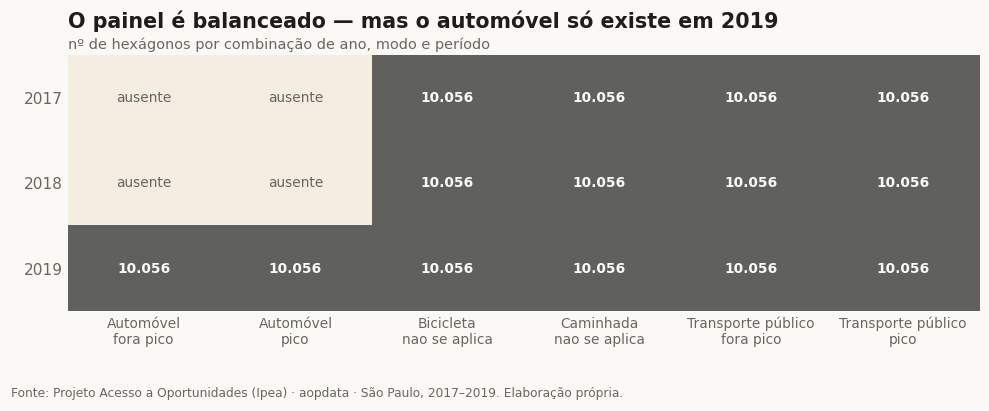

modo    automovel            bicicleta     caminhada transporte_publico       
periodo fora_pico   pico nao_se_aplica nao_se_aplica          fora_pico   pico
ano                                                                           
2017            0      0         10056         10056              10056  10056
2018            0      0         10056         10056              10056  10056
2019        10056  10056         10056         10056              10056  10056

In [5]:
painel = pd.crosstab(df.ano, [df.modo, df.periodo])
painel_hex = painel / df.id_hex.nunique()   # em "grades completas"

fig, ax = plt.subplots(figsize=(9, 3.4))
dados = painel_hex.values
im = ax.imshow(dados, cmap=SEQ, vmin=0, vmax=1.4, aspect="auto")

rot_col = [f"{ROTULO_MODO[m]}\n{p.replace('_', ' ')}" for m, p in painel_hex.columns]
ax.set_xticks(range(len(rot_col)), rot_col, fontsize=9)
ax.set_yticks(range(len(painel_hex)), painel_hex.index, fontsize=10)
for i in range(dados.shape[0]):
    for j in range(dados.shape[1]):
        v = dados[i, j]
        ax.text(j, i, "10.056" if v > 0 else "ausente", ha="center", va="center",
                color=PAPEL if v > 0.5 else GRAFITE, fontsize=9,
                fontweight="bold" if v > 0 else "normal")
titular(ax, "O painel é balanceado — mas o automóvel só existe em 2019",
        "nº de hexágonos por combinação de ano, modo e período")
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
rodape(fig, FONTE, y=-0.06)
plt.tight_layout(); plt.show()

painel

> **Achado 1 — o automóvel não serve para tendência.** Ele só existe em 2019.
> Comparações 2017→2019 usam transporte público, caminhada e bicicleta; o
> automóvel entra apenas como **linha de base do que a cidade permite** quando
> não se depende da rede de ônibus.
>
> Os modos ativos (caminhada, bicicleta) têm `periodo = nao_se_aplica` — não
> faz sentido pico ou fora-pico para quem anda a pé. Só transporte público e
> automóvel têm os dois períodos.

## Passo 1.3 — Os três blocos de colunas

As 69 colunas não são todas da mesma natureza, e tratá-las como se fossem é o
erro mais caro possível nesta base. `empregos_total` são os empregos **dentro**
do hexágono; `empregos_60min` são os empregos da cidade **alcançáveis a partir
dele**. Um é oferta local, o outro é acesso.

In [6]:
BLOCOS = {
    "identificacao": "Identificação — a chave e a geografia",
    "populacao_censo_2010": "Quem mora AQUI — Censo 2010, idêntico nos 3 anos",
    "renda_censo_2010": "Renda de quem mora AQUI — Censo 2010",
    "uso_do_solo_no_hexagono": "O que existe AQUI — varia com o ano",
    "acessibilidade_empregos": "O que se ALCANÇA daqui: empregos",
    "acessibilidade_servicos": "O que se ALCANÇA daqui: serviços",
    "tempo_ate_o_mais_proximo": "Minutos até o mais próximo — vazio = não alcançável",
}

# dicionário de colunas montado no notebook (espelha dados/saida/dicionario_variaveis.csv)
DIC = [
 ("id_hex","identificacao","Identificador único da célula H3 res 9"),
 ("ano","identificacao","Ano de referência: 2017, 2018 ou 2019"),
 ("modo","identificacao","Modo: transporte_publico, caminhada, bicicleta, automovel"),
 ("periodo","identificacao","pico (6h-8h), fora_pico (14h-16h) ou nao_se_aplica"),
 ("lon","identificacao","Longitude do centroide (WGS 84)"),
 ("lat","identificacao","Latitude do centroide (WGS 84)"),
 ("name_muni","identificacao","Nome do município"),
 ("code_muni","identificacao","Código IBGE do município"),
 ("pop_total","populacao_censo_2010","População residente — USE COMO PESO"),
 ("pop_homens","populacao_censo_2010","Homens (vem de P007; o dicionário do aopdata troca P006/P007)"),
 ("pop_mulheres","populacao_censo_2010","Mulheres (vem de P006)"),
 ("pop_branca","populacao_censo_2010","População branca"),
 ("pop_negra","populacao_censo_2010","População negra"),
 ("pop_indigena","populacao_censo_2010","População indígena"),
 ("pop_amarela","populacao_censo_2010","População amarela"),
 ("pop_00a05","populacao_censo_2010","0 a 5 anos"),
 ("pop_06a14","populacao_censo_2010","6 a 14 anos"),
 ("pop_15a18","populacao_censo_2010","15 a 18 anos"),
 ("pop_19a24","populacao_censo_2010","19 a 24 anos"),
 ("pop_25a39","populacao_censo_2010","25 a 39 anos"),
 ("pop_40a69","populacao_censo_2010","40 a 69 anos"),
 ("pop_70mais","populacao_censo_2010","70 anos ou mais"),
 ("renda_per_capita","renda_censo_2010","Renda per capita média, em R$ de 2010"),
 ("quintil_renda","renda_censo_2010","Quintil de renda (1 = mais pobres)"),
 ("decil_renda","renda_censo_2010","Decil de renda (1 = mais pobres, 10 = mais ricos)"),
 ("empregos_total","uso_do_solo_no_hexagono","Empregos localizados NESTE hexágono"),
 ("empregos_baixa_esc","uso_do_solo_no_hexagono","Empregos de baixa escolaridade aqui"),
 ("empregos_media_esc","uso_do_solo_no_hexagono","Empregos de média escolaridade aqui"),
 ("empregos_alta_esc","uso_do_solo_no_hexagono","Empregos de alta escolaridade aqui"),
 ("escolas_total","uso_do_solo_no_hexagono","Escolas públicas aqui"),
 ("escolas_infantil","uso_do_solo_no_hexagono","Escolas de ensino infantil aqui"),
 ("escolas_fundamental","uso_do_solo_no_hexagono","Escolas de ensino fundamental aqui"),
 ("escolas_medio","uso_do_solo_no_hexagono","Escolas de ensino médio aqui"),
 ("matriculas_total","uso_do_solo_no_hexagono","Matrículas em escolas públicas aqui"),
 ("matriculas_infantil","uso_do_solo_no_hexagono","Matrículas no infantil aqui"),
 ("matriculas_fundamental","uso_do_solo_no_hexagono","Matrículas no fundamental aqui"),
 ("matriculas_medio","uso_do_solo_no_hexagono","Matrículas no médio aqui"),
 ("saude_total","uso_do_solo_no_hexagono","Estabelecimentos de saúde aqui"),
 ("saude_baixa_compl","uso_do_solo_no_hexagono","Saúde de baixa complexidade aqui"),
 ("saude_media_compl","uso_do_solo_no_hexagono","Saúde de média complexidade aqui"),
 ("saude_alta_compl","uso_do_solo_no_hexagono","Saúde de alta complexidade aqui"),
 ("cras_total","uso_do_solo_no_hexagono","CRAS aqui"),
 ("empregos_15min","acessibilidade_empregos","Empregos ALCANÇÁVEIS em até 15 min"),
 ("empregos_30min","acessibilidade_empregos","Empregos alcançáveis em até 30 min"),
 ("empregos_45min","acessibilidade_empregos","Alcançáveis em 45 min — só caminhada e bicicleta"),
 ("empregos_60min","acessibilidade_empregos","Empregos alcançáveis em até 60 min"),
 ("empregos_90min","acessibilidade_empregos","Alcançáveis em 90 min — só TP e automóvel"),
 ("empregos_120min","acessibilidade_empregos","Alcançáveis em 120 min — só TP e automóvel"),
 ("empregos_baixa_esc_60min","acessibilidade_empregos","Empregos de baixa escolaridade em 60 min"),
 ("empregos_media_esc_60min","acessibilidade_empregos","Empregos de média escolaridade em 60 min"),
 ("empregos_alta_esc_60min","acessibilidade_empregos","Empregos de alta escolaridade em 60 min"),
 ("saude_30min","acessibilidade_servicos","Estabelecimentos de saúde em 30 min"),
 ("saude_60min","acessibilidade_servicos","Estabelecimentos de saúde em 60 min"),
 ("escolas_30min","acessibilidade_servicos","Escolas públicas em 30 min"),
 ("escolas_60min","acessibilidade_servicos","Escolas públicas em 60 min"),
 ("matriculas_30min","acessibilidade_servicos","Matrículas alcançáveis em 30 min"),
 ("matriculas_60min","acessibilidade_servicos","Matrículas alcançáveis em 60 min"),
 ("cras_30min","acessibilidade_servicos","CRAS alcançáveis em 30 min"),
 ("cras_60min","acessibilidade_servicos","CRAS alcançáveis em 60 min"),
 ("tempo_saude_qualquer","tempo_ate_o_mais_proximo","Minutos até a saúde mais próxima"),
 ("tempo_saude_baixa_compl","tempo_ate_o_mais_proximo","Minutos até saúde de baixa complexidade"),
 ("tempo_saude_media_compl","tempo_ate_o_mais_proximo","Minutos até saúde de média complexidade"),
 ("tempo_saude_alta_compl","tempo_ate_o_mais_proximo","Minutos até saúde de alta complexidade"),
 ("tempo_escola_qualquer","tempo_ate_o_mais_proximo","Minutos até a escola pública mais próxima"),
 ("tempo_escola_infantil","tempo_ate_o_mais_proximo","Minutos até a escola infantil mais próxima"),
 ("tempo_escola_fundamental","tempo_ate_o_mais_proximo","Minutos até o fundamental mais próximo"),
 ("tempo_escola_medio","tempo_ate_o_mais_proximo","Minutos até o ensino médio mais próximo"),
 ("tempo_cras","tempo_ate_o_mais_proximo","Minutos até o CRAS mais próximo"),
 ("pessoas_que_alcancam_60min","acessibilidade_servicos","Acessibilidade PASSIVA: pessoas que chegam AQUI em 60 min"),
]

dicionario = pd.DataFrame(DIC, columns=["coluna", "bloco", "descricao"])
dicionario["tipo"] = dicionario.coluna.map(df.dtypes.astype(str))
dicionario["nulos_%"] = dicionario.coluna.map((df.isna().mean() * 100).round(2))
dicionario["distintos"] = dicionario.coluna.map(df.nunique())
dicionario["bloco_descricao"] = dicionario.bloco.map(BLOCOS)

assert set(dicionario.coluna) == set(df.columns), "dicionário fora de sincronia com o CSV"
print("Dicionário cobre as 69 colunas do CSV. Resumo por bloco:")
dicionario.groupby("bloco_descricao").agg(
    colunas=("coluna", "size"), nulos_medio_pct=("nulos_%", "mean")).round(2)

Dicionário cobre as 69 colunas do CSV. Resumo por bloco:


,colunas,nulos_medio_pct
bloco_descricao,,
Identificação — a chave e a geografia,8,0.00
Minutos até o mais próximo — vazio = não alcançável,9,4.85
O que existe AQUI — varia com o ano,17,0.00
O que se ALCANÇA daqui: empregos,9,15.87
O que se ALCANÇA daqui: serviços,9,0.00
"Quem mora AQUI — Censo 2010, idêntico nos 3 anos",14,0.00
Renda de quem mora AQUI — Censo 2010,3,3.50


In [7]:
# dicionário completo — é a referência para o resto do notebook
dicionario[["coluna", "bloco", "tipo", "nulos_%", "distintos", "descricao"]]

,coluna,bloco,tipo,nulos_%,distintos,descricao
0,id_hex,identificacao,object,0.00,10056,Identificador único da célula H3 res 9
1,ano,identificacao,int64,0.00,3,"Ano de referência: 2017, 2018 ou 2019"
2,modo,identificacao,object,0.00,4,"Modo: transporte_publico, caminhada, bicicleta..."
3,periodo,identificacao,object,0.00,3,"pico (6h-8h), fora_pico (14h-16h) ou nao_se_ap..."
4,lon,identificacao,float64,0.00,10056,Longitude do centroide (WGS 84)
...,...,...,...,...,...,...
64,tempo_escola_infantil,tempo_ate_o_mais_proximo,float64,3.67,532,Minutos até a escola infantil mais próxima
65,tempo_escola_fundamental,tempo_ate_o_mais_proximo,float64,2.46,428,Minutos até o fundamental mais próximo
66,tempo_escola_medio,tempo_ate_o_mais_proximo,float64,2.63,427,Minutos até o ensino médio mais próximo
67,tempo_cras,tempo_ate_o_mais_proximo,float64,11.03,588,Minutos até o CRAS mais próximo


## Passo 1.4 — Padrão de valores ausentes

Aqui está a diferença mais importante desta base para um dataset tabular comum:

**quase todo `NaN` é informação, não defeito.**

Há três origens distintas, e cada uma pede um tratamento diferente:

1. **Corte de tempo que não existe naquele modo** — `empregos_45min` só foi
   publicado para caminhada e bicicleta; `empregos_90min`/`120min`, só para
   transporte público e automóvel. É ausência **estrutural**: 100% ou 0%, nunca
   no meio.
2. **Destino não alcançável dentro do limite de roteamento** — `tempo_*` vazio
   significa "não dá para chegar", não "não medimos". O limite difere por modo:
   60 min a pé, 90 de bicicleta, acima de 175 no transporte público.
3. **Hexágono sem moradores** — `renda_per_capita`, `quintil_renda` e
   `decil_renda` vazios nos 352 hexágonos com `pop_total = 0`. Sem morador, não
   há renda a estimar.

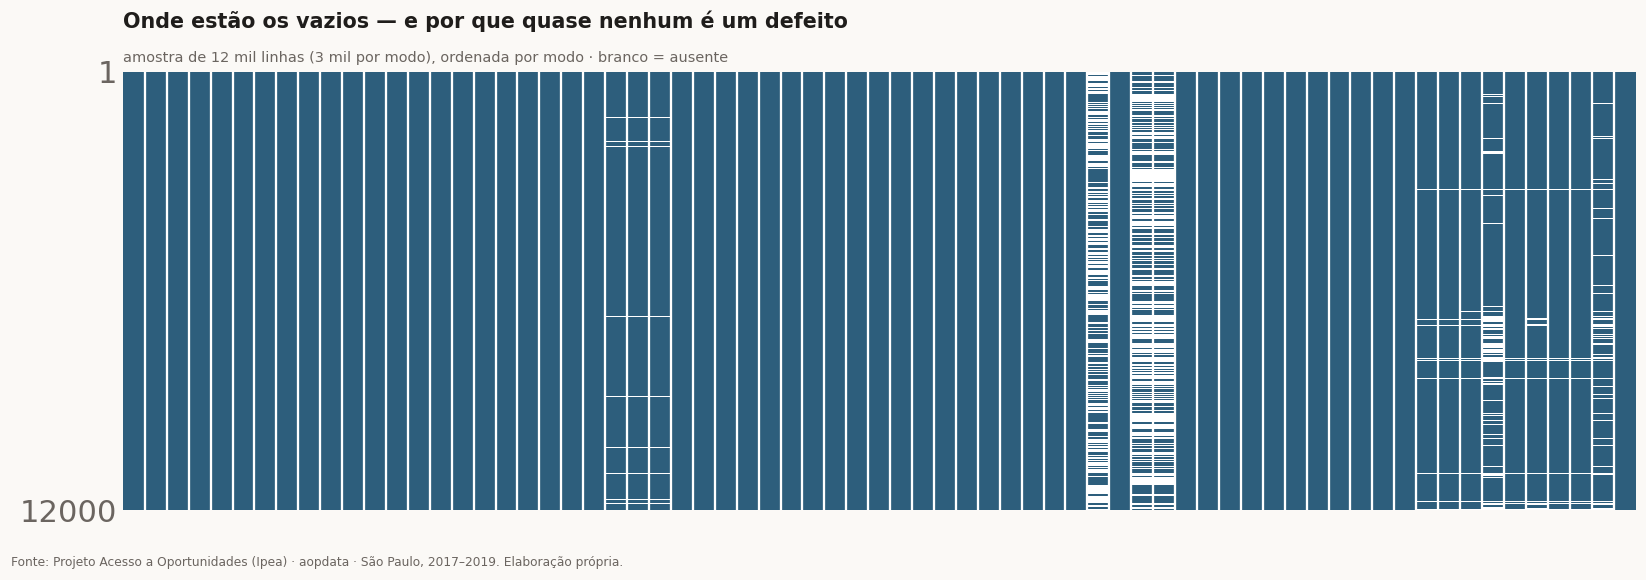

In [8]:
# visão matricial (amostra estratificada, para o padrão ficar legível)
amostra = df.groupby("modo", group_keys=False).sample(3000, random_state=42).sort_values(chave)

fig, ax = plt.subplots(figsize=(15, 5))
msno.matrix(amostra, ax=ax, sparkline=False, color=(0.18, 0.37, 0.49))
titular(ax, "Onde estão os vazios — e por que quase nenhum é um defeito",
        "amostra de 12 mil linhas (3 mil por modo), ordenada por modo · branco = ausente")
rodape(fig, FONTE, y=-0.02)
plt.tight_layout(); plt.show()

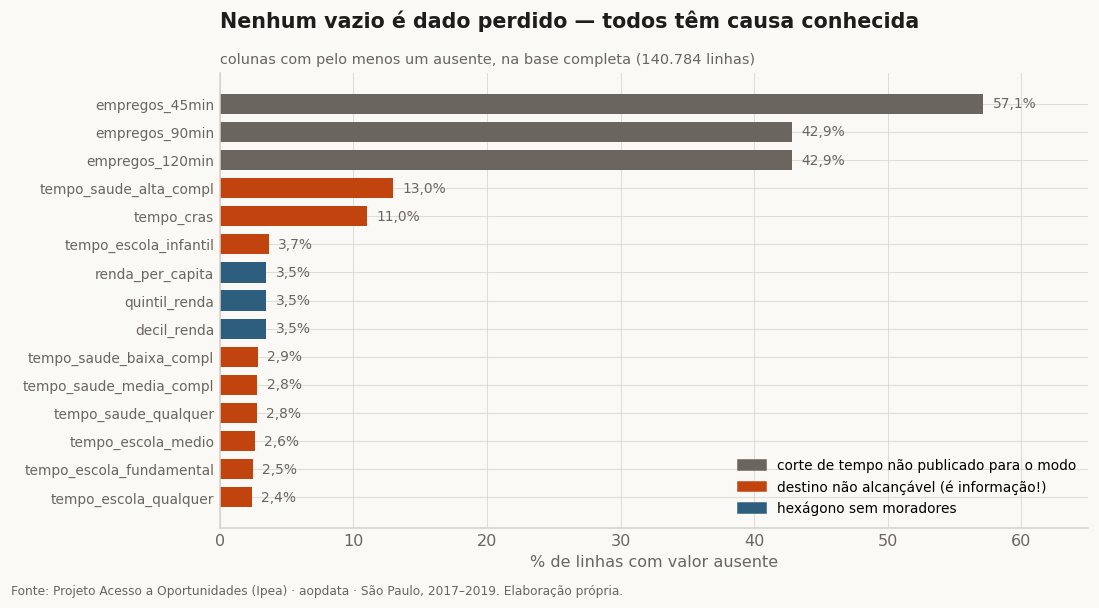

,coluna,pct_nulos,motivo
0,empregos_45min,57.14,corte não publicado para o modo (estrutural)
1,empregos_90min,42.86,corte não publicado para o modo (estrutural)
2,empregos_120min,42.86,corte não publicado para o modo (estrutural)
3,tempo_saude_alta_compl,12.96,destino não alcançável no limite de roteamento
4,tempo_cras,11.03,destino não alcançável no limite de roteamento
5,tempo_escola_infantil,3.67,destino não alcançável no limite de roteamento
6,renda_per_capita,3.50,hexágono sem moradores
7,quintil_renda,3.50,hexágono sem moradores
8,decil_renda,3.50,hexágono sem moradores
9,tempo_saude_baixa_compl,2.87,destino não alcançável no limite de roteamento


In [9]:
nulos = (df.isna().mean() * 100).round(2)
tabela_nulos = (pd.DataFrame({"coluna": nulos.index, "pct_nulos": nulos.values})
                .query("pct_nulos > 0").sort_values("pct_nulos", ascending=False)
                .merge(dicionario[["coluna", "bloco"]], on="coluna"))

MOTIVO = {
    "acessibilidade_empregos": "corte não publicado para o modo (estrutural)",
    "tempo_ate_o_mais_proximo": "destino não alcançável no limite de roteamento",
    "renda_censo_2010": "hexágono sem moradores",
}
tabela_nulos["motivo"] = tabela_nulos.bloco.map(MOTIVO)

fig, ax = plt.subplots(figsize=(10, 5.4))
cores = tabela_nulos.bloco.map({
    "acessibilidade_empregos": GRAFITE,
    "tempo_ate_o_mais_proximo": DESTAQUE,
    "renda_censo_2010": APOIO}).values
y = np.arange(len(tabela_nulos))[::-1]
ax.barh(y, tabela_nulos.pct_nulos, color=cores, height=0.72)
for yi, v in zip(y, tabela_nulos.pct_nulos):
    ax.text(v + 0.7, yi, f"{br(v, 1)}%", va="center", fontsize=9, color=GRAFITE)
ax.set_yticks(y, tabela_nulos.coluna, fontsize=9)
ax.set_xlabel("% de linhas com valor ausente")
ax.set_xlim(0, 65)
titular(ax, "Nenhum vazio é dado perdido — todos têm causa conhecida",
        "colunas com pelo menos um ausente, na base completa (140.784 linhas)")
ax.legend(handles=[
    Patch(color=GRAFITE, label="corte de tempo não publicado para o modo"),
    Patch(color=DESTAQUE, label="destino não alcançável (é informação!)"),
    Patch(color=APOIO, label="hexágono sem moradores")],
    loc="lower right", fontsize=9)
rodape(fig, FONTE, y=0.005)
plt.tight_layout(); plt.show()

tabela_nulos[["coluna", "pct_nulos", "motivo"]]

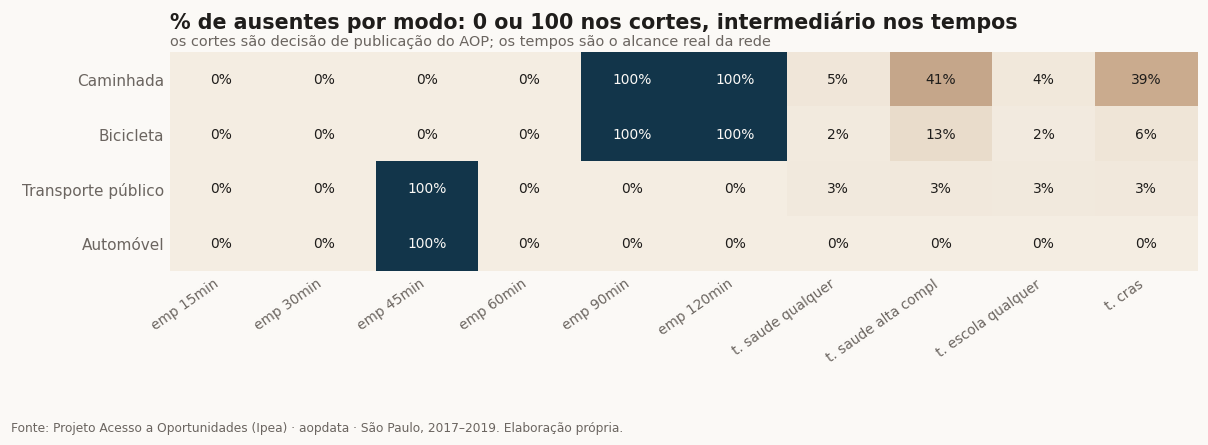

In [10]:
# a prova de que o vazio dos cortes é estrutural: 0% ou 100%, nunca no meio
cortes = ["empregos_15min", "empregos_30min", "empregos_45min",
          "empregos_60min", "empregos_90min", "empregos_120min"]
tempos = ["tempo_saude_qualquer", "tempo_saude_alta_compl",
          "tempo_escola_qualquer", "tempo_cras"]

por_modo = (df.groupby("modo")[cortes + tempos].apply(lambda d: d.isna().mean() * 100)
              .reindex(["caminhada", "bicicleta", "transporte_publico", "automovel"]))

fig, ax = plt.subplots(figsize=(11, 3.6))
im = ax.imshow(por_modo.values, cmap=SEQ, vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(por_modo.shape[1]),
              [c.replace("empregos_", "emp ").replace("tempo_", "t. ").replace("_", " ")
               for c in por_modo.columns], rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(por_modo)), [ROTULO_MODO[m] for m in por_modo.index], fontsize=10)
for i in range(por_modo.shape[0]):
    for j in range(por_modo.shape[1]):
        v = por_modo.values[i, j]
        ax.text(j, i, f"{v:.0f}%", ha="center", va="center", fontsize=9,
                color=PAPEL if v > 55 else TINTA)
titular(ax, "% de ausentes por modo: 0 ou 100 nos cortes, intermediário nos tempos",
        "os cortes são decisão de publicação do AOP; os tempos são o alcance real da rede")
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
rodape(fig, FONTE, y=-0.10)
plt.tight_layout(); plt.show()

> **Achado 2 — o `NaN` de `tempo_*` é o resultado mais eloquente da base.**
> Nos cortes de tempo o vazio é 0% ou 100%: é decisão de publicação do Ipea.
> Nos `tempo_*` ele é intermediário e **varia por modo** — 41% dos hexágonos
> não alcançam saúde de alta complexidade *a pé*, contra 3% por transporte
> público. Esse número não é um problema de qualidade de dado: é a medida
> direta do que a caminhada não resolve e o ônibus precisa resolver.
>
> **Consequência prática:** jamais imputar `tempo_*` com a média. Ou se trata
> como censura (com o limite do modo), ou se converte em uma variável binária
> "alcançável / não alcançável". Voltamos a isso na Parte 5.

## Passo 1.5 — Recortes de trabalho

Fixamos aqui os subconjuntos usados no resto do notebook, para não repetir
filtro em toda célula — e para deixar explícito **qual recorte gera cada
número**.

- `hab` — apenas hexágonos habitados (`pop_total > 0`). Descarta 352 hexágonos
  (3,5%) que são parque, represa, aeroporto ou área industrial pura.
- `tp19` — transporte público, 2019, **pico**. É o recorte do commute: a hora
  em que as pessoas vão trabalhar.
- `emp_cidade` — total de empregos da cidade em cada ano, o denominador que
  transforma "empregos alcançáveis" em "% dos empregos da cidade".

In [11]:
hexes = df.drop_duplicates("id_hex")
emp_cidade = df.drop_duplicates(["id_hex", "ano"]).groupby("ano").empregos_total.sum()

hab = df[df.pop_total > 0].copy()
hab["pct_empregos_60"] = hab.empregos_60min / hab.ano.map(emp_cidade) * 100
hab["pct_empregos_30"] = hab.empregos_30min / hab.ano.map(emp_cidade) * 100

tp   = hab[hab.modo == "transporte_publico"]
tp19 = tp[(tp.ano == 2019) & (tp.periodo == "pico")].copy()

print(f"hexágonos totais      : {br(len(hexes))}")
print(f"hexágonos habitados   : {br((hexes.pop_total > 0).sum())} "
      f"({(hexes.pop_total > 0).mean():.1%})")
print(f"população coberta     : {br(hexes.pop_total.sum())}")
print(f"empregos da cidade    : {emp_cidade.map(br).to_dict()}")
print(f"recorte tp19 (linhas) : {br(len(tp19))}")

hexágonos totais      : 10.056
hexágonos habitados   : 9.704 (96.5%)
população coberta     : 11.163.678
empregos da cidade    : {2017: '3.331.022', 2018: '3.313.612', 2019: '3.461.972'}
recorte tp19 (linhas) : 9.704


---

# 2 · Quem mora aqui

População e renda vêm do **Censo 2010** e são idênticas nos três anos. Isso é
uma limitação real (a cidade mudou entre 2010 e 2019), mas também uma vantagem
analítica: **a variação da acessibilidade entre 2017 e 2019 não pode ser
explicada por mudança demográfica.** O que muda é a rede e os empregos.

## Passo 2.1 — Distribuição da população pelos hexágonos

O primeiro gráfico do EDA precisa responder: os hexágonos são comparáveis entre
si? Não são — e é por isso que toda média daqui em diante é ponderada.

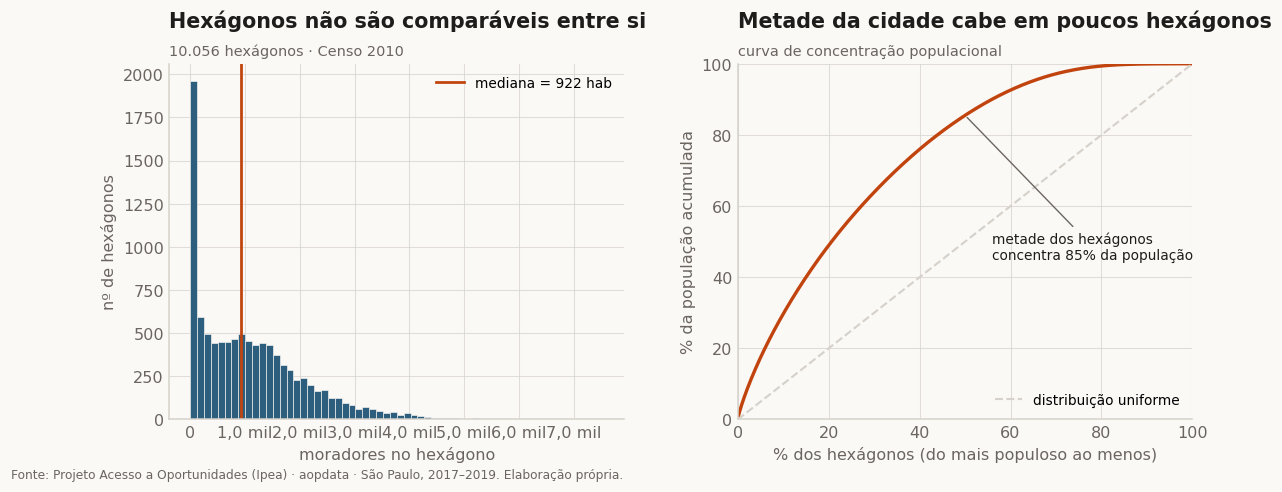

população total     : 11.163.678
hexágonos vazios    : 352
mediana / média     : 922 / 1.110
hexágono mais denso : 7.541 moradores em 0,105 km²


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"wspace": 0.25})

ax = axes[0]
ax.hist(hexes.pop_total, bins=60, color=APOIO, edgecolor=PAPEL, linewidth=0.4)
ax.axvline(hexes.pop_total.median(), color=DESTAQUE, lw=1.8,
           label=f"mediana = {br(hexes.pop_total.median())} hab")
ax.set_xlabel("moradores no hexágono"); ax.set_ylabel("nº de hexágonos")
ax.xaxis.set_major_formatter(EIXO_MIL)
ax.legend(loc="upper right", fontsize=9)
titular(ax, "Hexágonos não são comparáveis entre si",
        f"{br(len(hexes))} hexágonos · Censo 2010")

# curva de concentração: % da população em % dos hexágonos
ax = axes[1]
p = np.sort(hexes.pop_total.values)[::-1]
acum = np.cumsum(p) / p.sum() * 100
eixo = np.arange(1, len(p) + 1) / len(p) * 100
ax.plot(eixo, acum, color=DESTAQUE, lw=2.2)
ax.plot([0, 100], [0, 100], color=NEVOA, lw=1.4, ls="--", label="distribuição uniforme")
meta = np.interp(50, eixo, acum)
ax.annotate(f"metade dos hexágonos\nconcentra {meta:.0f}% da população",
            xy=(50, meta), xytext=(56, 45), fontsize=9, color=TINTA,
            arrowprops=dict(arrowstyle="-", color=GRAFITE, lw=0.9))
ax.set_xlabel("% dos hexágonos (do mais populoso ao menos)")
ax.set_ylabel("% da população acumulada")
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.legend(loc="lower right", fontsize=9)
titular(ax, "Metade da cidade cabe em poucos hexágonos",
        "curva de concentração populacional")

rodape(fig, FONTE)
plt.tight_layout(); plt.show()

print(f"população total     : {br(hexes.pop_total.sum())}")
print(f"hexágonos vazios    : {br((hexes.pop_total == 0).sum())}")
print(f"mediana / média     : {br(hexes.pop_total.median())} / {br(hexes.pop_total.mean())}")
print(f"hexágono mais denso : {br(hexes.pop_total.max())} moradores em 0,105 km²")

## Passo 2.2 — O mapa da cidade: onde estão as pessoas e onde está o dinheiro

Dois mapas lado a lado. O da esquerda é onde a cidade **mora**; o da direita é
onde ela **ganha**. A leitura combinada dos dois já antecipa o problema do
commute: os dois padrões não coincidem.

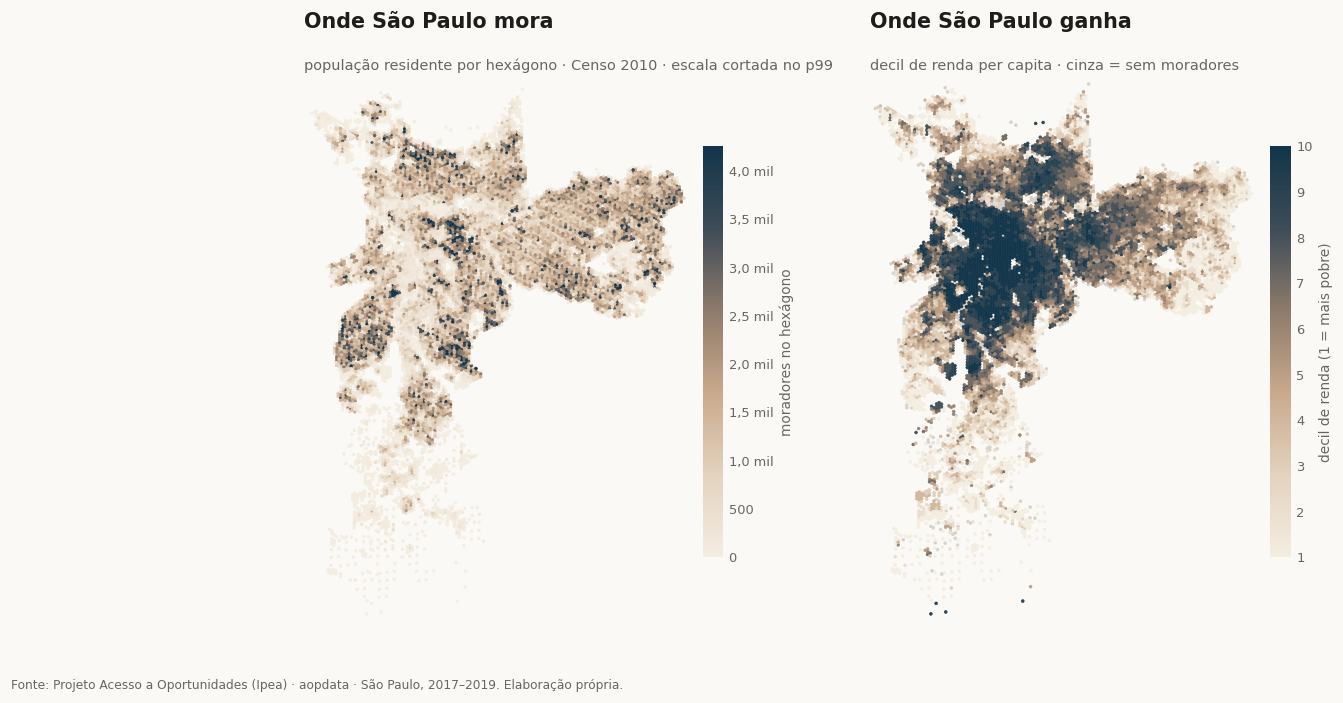

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.4), gridspec_kw={"wspace": 0.05})

mapa_hex(axes[0], hexes, "pop_total", vmax=hexes.pop_total.quantile(0.99),
         rotulo_escala="moradores no hexágono",
         titulo="Onde São Paulo mora",
         subtitulo="população residente por hexágono · Censo 2010 · escala cortada no p99")

d = hexes.copy()
d.loc[d.pop_total == 0, "decil_renda"] = np.nan
mapa_hex(axes[1], d, "decil_renda", vmin=1, vmax=10, fmt=None,
         rotulo_escala="decil de renda (1 = mais pobre)",
         titulo="Onde São Paulo ganha",
         subtitulo="decil de renda per capita · cinza = sem moradores")

rodape(fig, FONTE, y=0.03)
plt.show()

> **Achado 3 — o gradiente de renda é radial e nítido.** Os decis altos formam
> um bloco contínuo no centro-sudoeste (Pinheiros, Itaim, Moema, Jardins); os
> decis 1 e 2 formam um anel externo quase completo. Não é um mosaico
> aleatório: é uma cidade com **centro rico e periferia pobre**, e qualquer
> medida de acesso que dependa de distância ao centro vai reproduzir esse
> desenho.

## Passo 2.3 — Quem é a população de cada decil

Antes de medir acesso, vale saber **quem** está em cada decil. A composição por
cor e por faixa etária mostra que "decil de renda" nesta base é também um
recorte racial e etário — o que muda a leitura política de qualquer achado de
acesso.

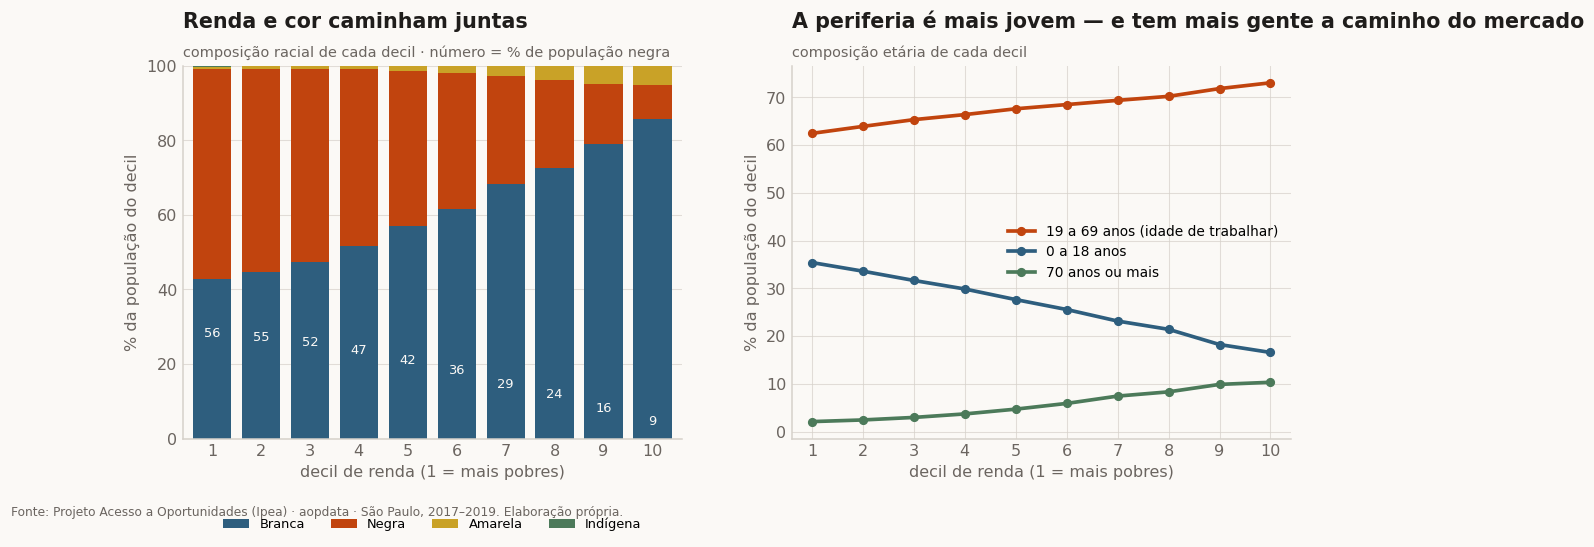

,população,% negra,% 0-18,% 19-69,renda per capita média (R$ 2010)
decil_renda,,,,,
1.00,1115320,56.40,35.40,62.50,318.00
2.00,1119044,54.60,33.60,63.90,424.00
3.00,1114185,51.90,31.70,65.40,483.00
4.00,1115266,47.40,29.90,66.40,545.00
5.00,1118000,41.70,27.70,67.60,631.00
6.00,1118140,36.40,25.60,68.50,742.00
7.00,1114487,28.90,23.20,69.40,920.00
8.00,1115800,23.60,21.40,70.20,"1,251.00"
9.00,1116755,16.00,18.20,71.90,"1,996.00"


In [14]:
pop_cols_raca = ["pop_branca", "pop_negra", "pop_amarela", "pop_indigena"]
pop_cols_idade = ["pop_00a05", "pop_06a14", "pop_15a18", "pop_19a24",
                  "pop_25a39", "pop_40a69", "pop_70mais"]

perfil = (hexes.dropna(subset=["decil_renda"])
          .groupby("decil_renda")[["pop_total"] + pop_cols_raca + pop_cols_idade].sum())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"wspace": 0.22})

ax = axes[0]
raca_pct = perfil[pop_cols_raca].div(perfil[pop_cols_raca].sum(axis=1), axis=0) * 100
cores_raca = [APOIO, DESTAQUE, AREIA, VERDE]
rot_raca = ["Branca", "Negra", "Amarela", "Indígena"]
base = np.zeros(len(raca_pct))
for col, cor, rot in zip(pop_cols_raca, cores_raca, rot_raca):
    ax.bar(raca_pct.index, raca_pct[col], bottom=base, color=cor, width=0.78, label=rot)
    base += raca_pct[col].values
for x, v in zip(raca_pct.index, raca_pct.pop_negra):
    ax.text(x, v / 2, f"{v:.0f}", ha="center", va="center", color=PAPEL, fontsize=8.5)
ax.set_xticks(range(1, 11)); ax.set_xlim(0.4, 10.6); ax.set_ylim(0, 100)
ax.set_xlabel("decil de renda (1 = mais pobres)"); ax.set_ylabel("% da população do decil")
ax.legend(ncol=4, fontsize=8.5, loc="upper center", bbox_to_anchor=(0.5, -0.18))
titular(ax, "Renda e cor caminham juntas",
        "composição racial de cada decil · número = % de população negra")

ax = axes[1]
idade_pct = perfil[pop_cols_idade].div(perfil[pop_cols_idade].sum(axis=1), axis=0) * 100
economicamente_ativa = idade_pct[["pop_19a24", "pop_25a39", "pop_40a69"]].sum(axis=1)
criancas = idade_pct[["pop_00a05", "pop_06a14", "pop_15a18"]].sum(axis=1)
ax.plot(idade_pct.index, economicamente_ativa, color=DESTAQUE, lw=2.4,
        marker="o", ms=5, label="19 a 69 anos (idade de trabalhar)")
ax.plot(idade_pct.index, criancas, color=APOIO, lw=2.4, marker="o", ms=5,
        label="0 a 18 anos")
ax.plot(idade_pct.index, idade_pct.pop_70mais, color=VERDE, lw=2.4, marker="o", ms=5,
        label="70 anos ou mais")
ax.set_xticks(range(1, 11)); ax.set_xlim(0.6, 10.4)
ax.set_xlabel("decil de renda (1 = mais pobres)"); ax.set_ylabel("% da população do decil")
ax.legend(fontsize=9, loc="center right")
titular(ax, "A periferia é mais jovem — e tem mais gente a caminho do mercado",
        "composição etária de cada decil")

rodape(fig, FONTE, y=-0.03)
plt.tight_layout(); plt.show()

perfil_resumo = pd.DataFrame({
    "população": perfil.pop_total,
    "% negra": (perfil.pop_negra / perfil[pop_cols_raca].sum(axis=1) * 100).round(1),
    "% 0-18": criancas.round(1),
    "% 19-69": economicamente_ativa.round(1),
    "renda per capita média (R$ 2010)": hexes.dropna(subset=["decil_renda"])
        .groupby("decil_renda").apply(lambda d: pond(d.renda_per_capita, d.pop_total),
                                      include_groups=False).round(0),
})
perfil_resumo

---

# 3 · O que existe aqui — uso do solo

Empregos, escolas, saúde e CRAS **dentro** de cada hexágono. É a oferta local,
antes de qualquer transporte. Esta parte existe para estabelecer o contraste que
sustenta o problem statement: **equipamento de bairro é distribuído; emprego
não é.**

## Passo 3.1 — A concentração de empregos

Curva de Lorenz de quatro oportunidades. Quanto mais a curva se afasta da
diagonal, mais concentrada a oportunidade está em poucos hexágonos.

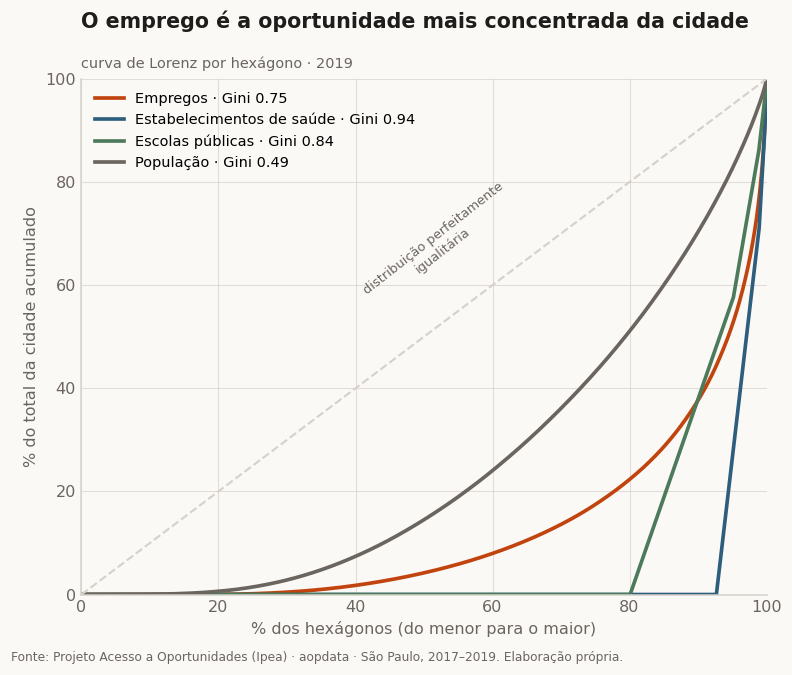

,oportunidade,gini,% em 5% dos hexágonos,% de hexágonos com zero
0,Empregos,0.75,47.70,15.80
1,Estabelecimentos de saúde,0.94,73.40,92.70
2,Escolas públicas,0.84,43.00,80.10
3,População,0.49,17.40,3.50


In [15]:
uso19 = df[df.ano == 2019].drop_duplicates("id_hex")

def lorenz(v):
    v = np.sort(np.asarray(v, dtype=float))
    return np.insert(np.cumsum(v) / v.sum(), 0, 0) * 100

def gini(v):
    v = np.sort(np.asarray(v, dtype=float))
    n = len(v)
    return (2 * np.sum((np.arange(1, n + 1)) * v) / (n * v.sum())) - (n + 1) / n

alvos = [("empregos_total", "Empregos", DESTAQUE),
         ("saude_total", "Estabelecimentos de saúde", APOIO),
         ("escolas_total", "Escolas públicas", VERDE),
         ("pop_total", "População", GRAFITE)]

fig, ax = plt.subplots(figsize=(7.4, 6))
eixo = np.linspace(0, 100, len(uso19) + 1)
for col, rot, cor in alvos:
    ax.plot(eixo, lorenz(uso19[col]), color=cor, lw=2.4,
            label=f"{rot} · Gini {gini(uso19[col]):.2f}")
ax.plot([0, 100], [0, 100], color=NEVOA, lw=1.4, ls="--")
ax.text(52, 56, "distribuição perfeitamente\nigualitária", fontsize=8.5,
        color=GRAFITE, rotation=38, ha="center")
ax.set_xlabel("% dos hexágonos (do menor para o maior)")
ax.set_ylabel("% do total da cidade acumulado")
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.legend(loc="upper left", fontsize=9.5)
titular(ax, "O emprego é a oportunidade mais concentrada da cidade",
        "curva de Lorenz por hexágono · 2019")
rodape(fig, FONTE)
plt.tight_layout(); plt.show()

conc = pd.DataFrame({
    "oportunidade": [r for _, r, _ in alvos],
    "gini": [round(gini(uso19[c]), 3) for c, _, _ in alvos],
    "% em 5% dos hexágonos": [
        round(uso19[c].nlargest(int(len(uso19) * 0.05)).sum() / uso19[c].sum() * 100, 1)
        for c, _, _ in alvos],
    "% de hexágonos com zero": [round((uso19[c] == 0).mean() * 100, 1) for c, _, _ in alvos],
})
conc

> **Achado 4 — 5% dos hexágonos concentram 47,7% dos empregos e apenas 17,4%
> da população.** O Gini dos empregos é 0,75 contra 0,49 da população: **a
> oportunidade se concentra muito mais do que a moradia.** É exatamente esse
> descasamento que cria o commute — se emprego e moradia estivessem igualmente
> distribuídos, não haveria deslocamento pendular a explicar.
>
> *Ressalva de leitura:* saúde e escola aparecem com Gini ainda mais alto (0,94
> e 0,84), mas isso é artefato de serem **equipamentos indivisíveis** — 92,7%
> dos hexágonos têm zero estabelecimentos de saúde simplesmente porque um posto
> atende um raio, não um hexágono de 0,1 km². Para esses, a métrica honesta é o
> **tempo até o mais próximo**, e é o que fazemos na Parte 5.

## Passo 3.2 — Onde estão as oportunidades

Quatro mapas na mesma escala relativa. O olho compara o **desenho**, não o
número: emprego tem um núcleo, saúde e escola têm capilaridade.

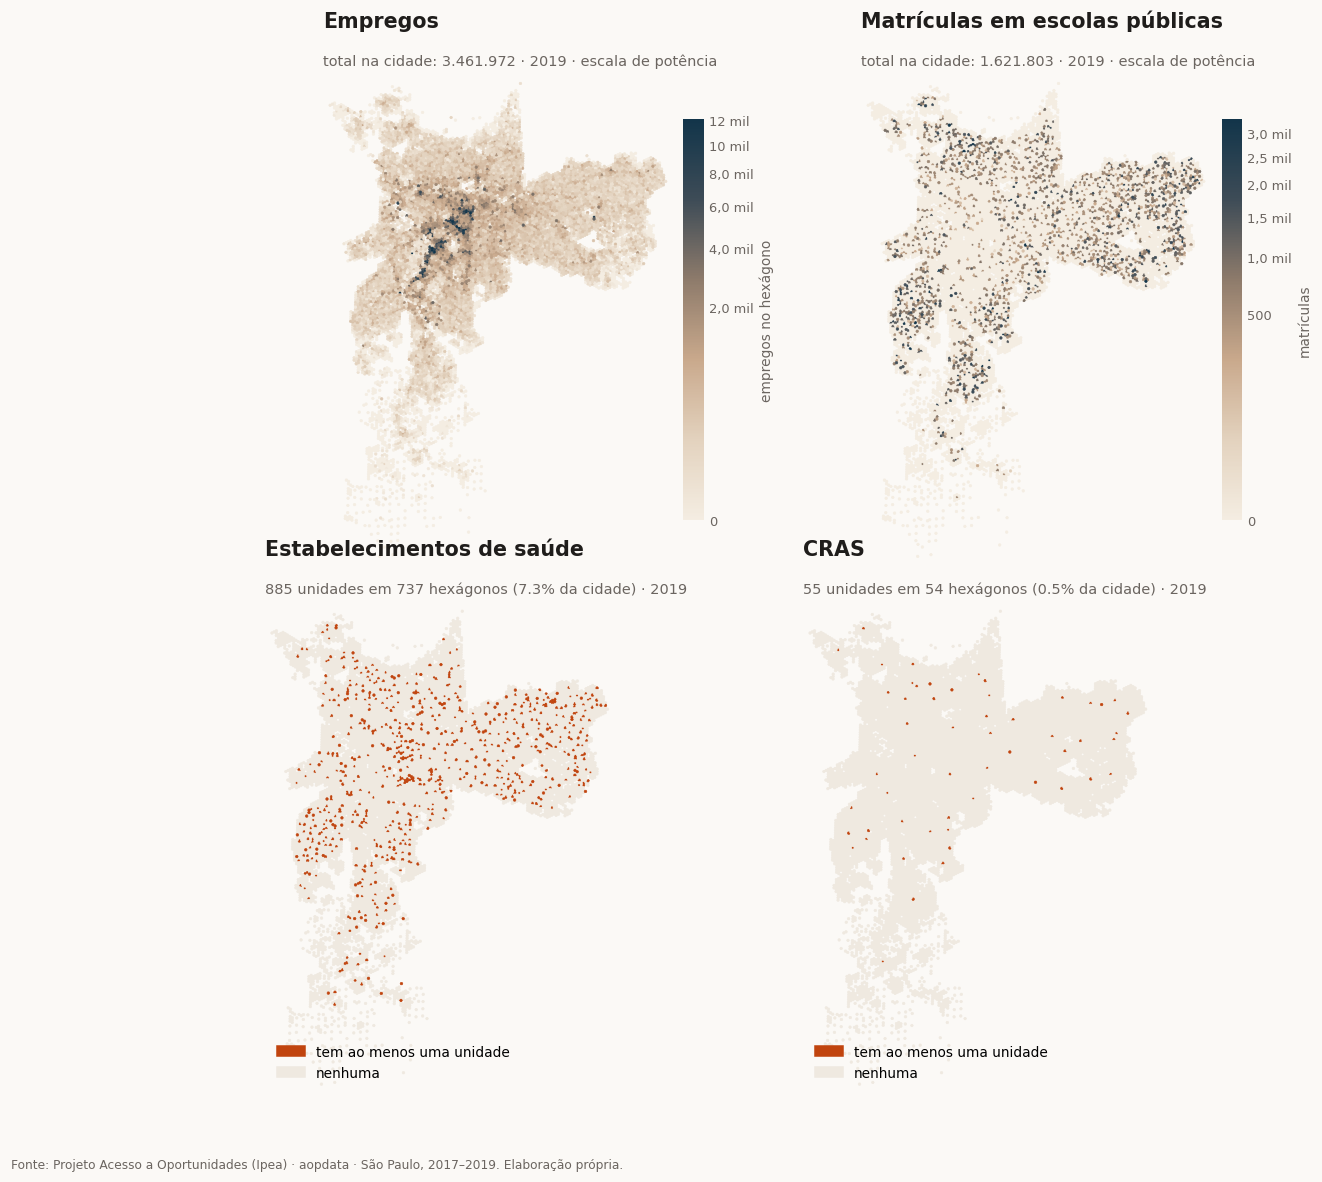

In [16]:
from matplotlib.colors import PowerNorm

PRESENCA = LinearSegmentedColormap.from_list("presenca", ["#EFE9E0", DESTAQUE])

fig, axes = plt.subplots(2, 2, figsize=(12.5, 12), gridspec_kw={"hspace": 0.08, "wspace": 0.02})

# linha 1 — densidade. Escala de potência: a distribuição é assimétrica demais
# para escala linear (5% dos hexágonos levariam toda a paleta).
for ax, (col, titulo, rotulo) in zip(axes[0], [
        ("empregos_total", "Empregos", "empregos no hexágono"),
        ("matriculas_total", "Matrículas em escolas públicas", "matrículas")]):
    mapa_hex(ax, uso19, col,
             norm=PowerNorm(0.35, vmin=0, vmax=uso19[col].quantile(0.999)),
             rotulo_escala=rotulo, titulo=titulo,
             subtitulo=f"total na cidade: {br(uso19[col].sum())} · 2019 · escala de potência")

# linha 2 — presença. Contagens de 0 a 3 não rendem choropleth: o que importa
# é ter ou não ter o equipamento dentro do hexágono.
for ax, (col, titulo) in zip(axes[1], [("saude_total", "Estabelecimentos de saúde"),
                                       ("cras_total", "CRAS")]):
    d = uso19.assign(presenca=(uso19[col] > 0).astype(float))
    mapa_hex(ax, d, "presenca", cmap=PRESENCA, vmin=0, vmax=1, escala=False,
             titulo=titulo,
             subtitulo=(f"{br(uso19[col].sum())} unidades em "
                        f"{br((uso19[col] > 0).sum())} hexágonos "
                        f"({(uso19[col] > 0).mean():.1%} da cidade) · 2019"))
    ax.legend(handles=[Patch(color=DESTAQUE, label="tem ao menos uma unidade"),
                       Patch(color="#EFE9E0", label="nenhuma")],
              loc="lower left", fontsize=9)

rodape(fig, FONTE, y=0.06)
plt.show()

> **Achado 5 — o mapa do emprego é o mapa da renda alta, girado.** O núcleo de
> empregos (centro expandido + vetor sudoeste, Faria Lima/Berrini) coincide com
> os decis 9 e 10 do mapa do Passo 2.2. Quem mora perto do emprego já é quem
> ganha mais; quem mora longe paga o commute **duas vezes** — em tempo e em
> tarifa.

---

# 4 · O que se alcança daqui — acessibilidade a empregos

O núcleo do trabalho. Todas as medidas aqui são **acessibilidade ativa**:
quantos empregos da cidade uma pessoa que mora neste hexágono alcança dentro de
um tempo de viagem.

Recorte padrão: **transporte público, pico, 2019**, salvo indicação contrária.

## Passo 4.1 — Quanto da cidade cada modo entrega

O primeiro número do commute. `empregos_60min` dividido pelo total de empregos
da cidade responde: *que fração do mercado de trabalho de São Paulo está ao
alcance de uma hora de viagem?*

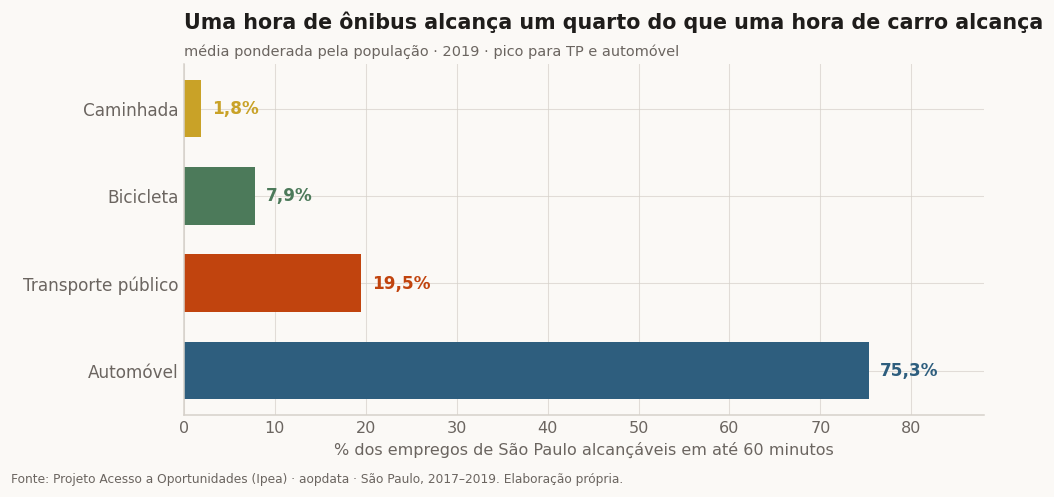

,emp_15min,emp_30min,emp_60min,pct_60min
modo,,,,
caminhada,"3,715.90","15,726.20","63,846.50",1.80
bicicleta,"16,929.00","68,546.80","271,949.00",7.90
transporte_publico,"5,796.80","64,018.90","675,924.10",19.50
automovel,"158,631.80","850,677.00","2,608,056.50",75.30


In [17]:
m19 = hab[(hab.ano == 2019) & (hab.periodo != "fora_pico")]
resumo_modo = (m19.groupby("modo")
    .apply(lambda d: pd.Series({
        "emp_15min": pond(d.empregos_15min, d.pop_total),
        "emp_30min": pond(d.empregos_30min, d.pop_total),
        "emp_60min": pond(d.empregos_60min, d.pop_total),
        "pct_60min": pond(d.pct_empregos_60, d.pop_total),
    }), include_groups=False)
    .reindex(["caminhada", "bicicleta", "transporte_publico", "automovel"]))

fig, ax = plt.subplots(figsize=(9.5, 4.4))
y = np.arange(len(resumo_modo))[::-1]
cores = [CORES_MODO[m] for m in resumo_modo.index]
ax.barh(y, resumo_modo.pct_60min, color=cores, height=0.66)
for yi, (m, v) in zip(y, resumo_modo.pct_60min.items()):
    ax.text(v + 1.2, yi, f"{br(v, 1)}%", va="center", fontsize=11,
            fontweight="bold", color=CORES_MODO[m])
ax.set_yticks(y, [ROTULO_MODO[m] for m in resumo_modo.index], fontsize=11)
ax.set_xlabel("% dos empregos de São Paulo alcançáveis em até 60 minutos")
ax.set_xlim(0, 88)
titular(ax, "Uma hora de ônibus alcança um quarto do que uma hora de carro alcança",
        "média ponderada pela população · 2019 · pico para TP e automóvel")
rodape(fig, FONTE)
plt.tight_layout(); plt.show()

resumo_modo.round(1)

> **Achado 6 — o paulistano médio alcança 19,5% dos empregos da cidade em uma
> hora de transporte público, contra 75,3% de automóvel.** É o número da V1
> (20,2%), reproduzido em base independente e com metodologia do Ipea. A razão
> é de quase **4 para 1**: o carro não é uma comodidade, é um multiplicador de
> mercado de trabalho. E a caminhada entrega 1,8% — ou seja, para a esmagadora
> maioria dos paulistanos o emprego **não é uma opção local**, o deslocamento
> motorizado é obrigatório.

## Passo 4.2 — A curva de acesso: quanto tempo custa cada fatia da cidade

Em vez de olhar um único corte, olhamos a **curva inteira**. Cada ponto é o
percentual médio dos empregos alcançáveis naquele tempo de viagem. A inclinação
da curva é o que interessa: ela mostra quanto de mercado se "compra" com cada
meia hora a mais de vida no trânsito.

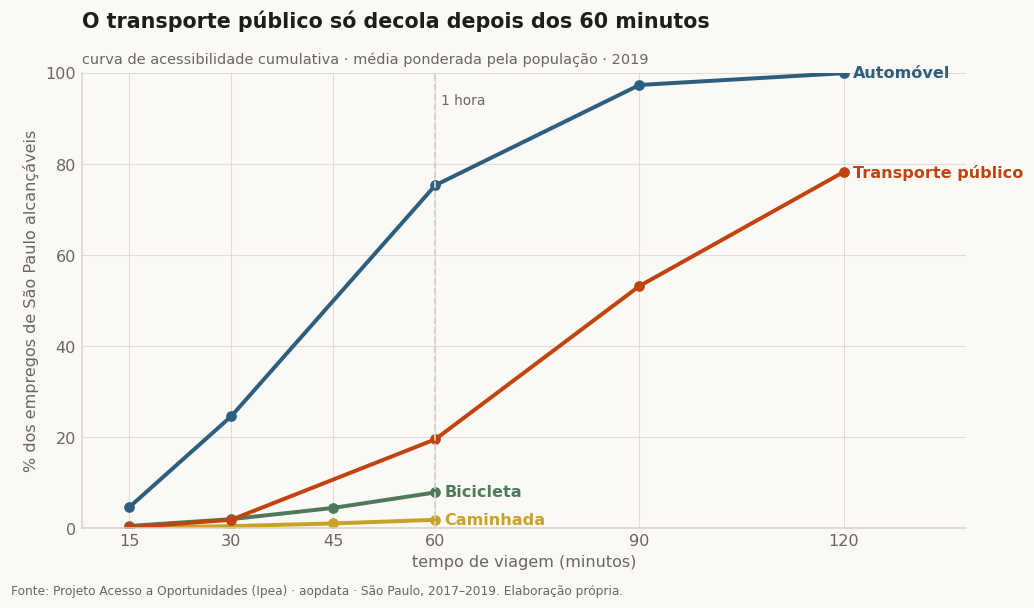

modo,automovel,bicicleta,caminhada,transporte_publico
minutos,,,,
15,4.60,0.50,0.10,0.20
30,24.60,2.00,0.50,1.80
45,NaN,4.50,1.00,NaN
60,75.30,7.90,1.80,19.50
90,97.40,NaN,NaN,53.20
120,99.90,NaN,NaN,78.20


In [18]:
CORTES = {"empregos_15min": 15, "empregos_30min": 30, "empregos_45min": 45,
          "empregos_60min": 60, "empregos_90min": 90, "empregos_120min": 120}

curvas = []
for modo, d in m19.groupby("modo"):
    for col, minutos in CORTES.items():
        if d[col].notna().any():
            curvas.append({"modo": modo, "minutos": minutos,
                           "pct": pond(d[col], d.pop_total) / emp_cidade[2019] * 100})
curvas = pd.DataFrame(curvas)

fig, ax = plt.subplots(figsize=(9.5, 5.4))
for modo, d in curvas.groupby("modo"):
    d = d.sort_values("minutos")
    ax.plot(d["minutos"], d.pct, color=CORES_MODO[modo], lw=2.6, marker="o", ms=6)
    ax.annotate(ROTULO_MODO[modo], xy=(d["minutos"].iloc[-1], d.pct.iloc[-1]),
                xytext=(6, 0), textcoords="offset points", va="center",
                fontsize=10.5, fontweight="bold", color=CORES_MODO[modo])
ax.axvline(60, color=NEVOA, lw=1.2, ls="--")
ax.text(60.8, 93, "1 hora", fontsize=9, color=GRAFITE)
ax.set_xticks([15, 30, 45, 60, 90, 120])
ax.set_xlabel("tempo de viagem (minutos)")
ax.set_ylabel("% dos empregos de São Paulo alcançáveis")
ax.set_xlim(8, 138); ax.set_ylim(0, 100)
titular(ax, "O transporte público só decola depois dos 60 minutos",
        "curva de acessibilidade cumulativa · média ponderada pela população · 2019")
rodape(fig, FONTE)
plt.tight_layout(); plt.show()

curvas.pivot(index="minutos", columns="modo", values="pct").round(1)

> **Achado 7 — meia hora de transporte público entrega 1,8% dos empregos: o
> mesmo que uma hora inteira a pé.** A curva do TP só ganha inclinação depois
> dos 30 minutos e só cruza a marca dos 50% perto dos 90. O automóvel entrega
> em 15 minutos (4,6%) mais do que o ônibus entrega em 30.
>
> Isso descreve uma rede desenhada para **viagem longa e troncal**, não para
> deslocamento curto: o transporte público de São Paulo só "compensa" depois
> que a pessoa já aceitou perder mais de uma hora. Em 120 minutos ele chega a
> 78% da cidade — o acesso existe, mas custa **duas horas por trecho, quatro
> por dia**.

## Passo 4.3 — O mapa do commute

O gráfico central do trabalho: quanto do mercado de trabalho da cidade cada
lugar alcança em uma hora de ônibus, no horário em que as pessoas vão trabalhar.

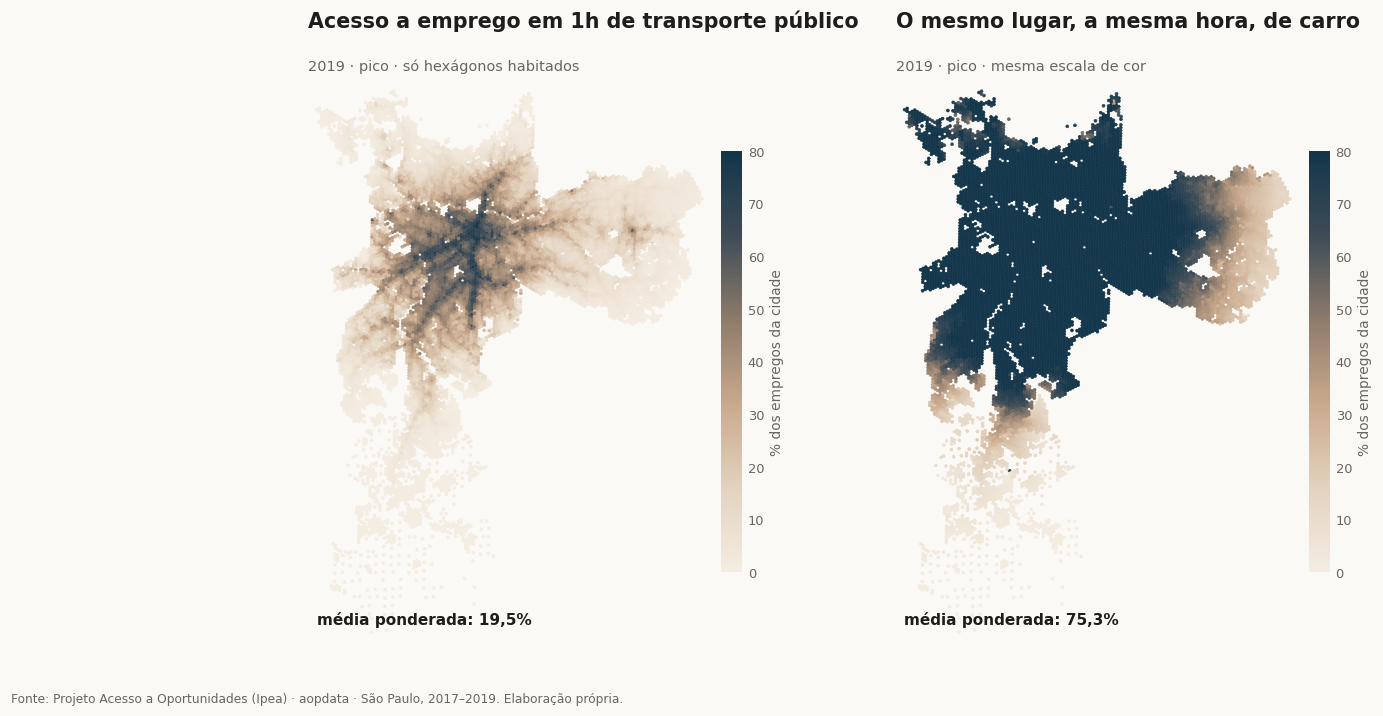

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13.4, 6.6), gridspec_kw={"wspace": 0.06})

mapa_hex(axes[0], tp19, "pct_empregos_60", vmin=0, vmax=80, fmt=None,
         rotulo_escala="% dos empregos da cidade",
         titulo="Acesso a emprego em 1h de transporte público",
         subtitulo="2019 · pico · só hexágonos habitados")
axes[0].text(0.02, 0.03, f"média ponderada: {br(pond(tp19.pct_empregos_60, tp19.pop_total), 1)}%",
             transform=axes[0].transAxes, fontsize=10, color=TINTA, fontweight="bold")

carro19 = hab[(hab.ano == 2019) & (hab.modo == "automovel") & (hab.periodo == "pico")]
mapa_hex(axes[1], carro19, "pct_empregos_60", vmin=0, vmax=80, fmt=None,
         rotulo_escala="% dos empregos da cidade",
         titulo="O mesmo lugar, a mesma hora, de carro",
         subtitulo="2019 · pico · mesma escala de cor")
axes[1].text(0.02, 0.03, f"média ponderada: {br(pond(carro19.pct_empregos_60, carro19.pop_total), 1)}%",
             transform=axes[1].transAxes, fontsize=10, color=TINTA, fontweight="bold")

rodape(fig, FONTE, y=0.04)
plt.show()

> **Achado 8 — o mapa do transporte público é uma ilha; o do carro é a cidade
> inteira.** Na mesma escala de cor, o TP produz uma mancha clara concentrada
> no centro expandido, com toda a periferia em tom escuro; o automóvel cobre
> quase toda a área urbanizada. A diferença entre os dois mapas **é o problema**
> — e ela não é de infraestrutura viária, já que os dois modos usam o mesmo
> território.

## Passo 4.4 — O gradiente de renda

Aqui o EDA encontra o problem statement. Repetimos a curva do Passo 4.2, mas
uma linha por decil de renda — é a versão em dados do slide "a desigualdade de
destinos".

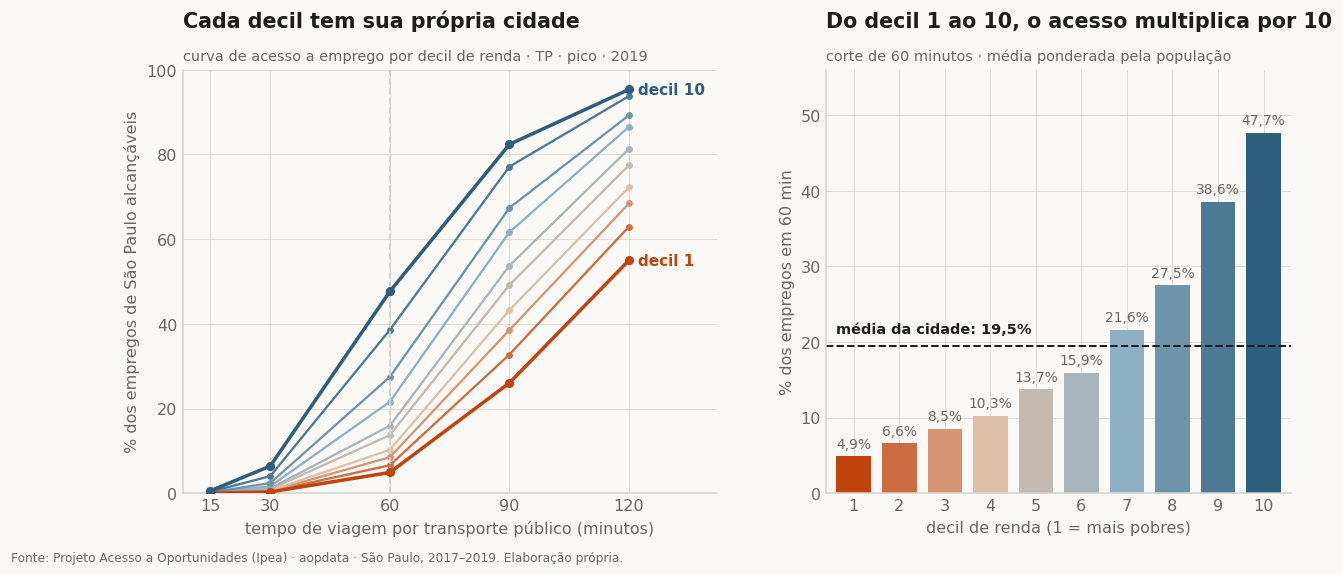

,população,empregos_60min,% dos empregos,empregos_30min,tempo até saúde alta (min),renda per capita (R$ 2010)
decil_renda,,,,,,
1.00,"1,115,320.00","169,770.80",4.90,"10,812.10",40.90,317.80
2.00,"1,119,044.00","228,623.90",6.60,"15,322.10",34.60,423.80
3.00,"1,114,185.00","294,648.70",8.50,"17,776.40",32.40,483.40
4.00,"1,115,266.00","355,051.20",10.30,"22,292.00",29.40,544.80
5.00,"1,118,000.00","474,991.60",13.70,"32,349.10",27.30,630.60
6.00,"1,118,140.00","551,905.80",15.90,"39,090.30",26.00,741.70
7.00,"1,114,487.00","747,759.90",21.60,"57,075.10",25.30,920.00
8.00,"1,115,800.00","951,344.70",27.50,"83,437.60",22.90,"1,250.80"
9.00,"1,116,755.00","1,335,205.60",38.60,"139,820.10",20.30,"1,996.20"


In [20]:
CORTES_TP = {"empregos_15min": 15, "empregos_30min": 30, "empregos_60min": 60,
             "empregos_90min": 90, "empregos_120min": 120}

curva_decil = []
for decil, d in tp19.dropna(subset=["decil_renda"]).groupby("decil_renda"):
    for col, minutos in CORTES_TP.items():
        curva_decil.append({"decil": int(decil), "minutos": minutos,
                            "pct": pond(d[col], d.pop_total) / emp_cidade[2019] * 100})
curva_decil = pd.DataFrame(curva_decil)

cmap_decil = LinearSegmentedColormap.from_list("d", [DESTAQUE, "#E0BFA8", "#8FB0C4", APOIO])

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"wspace": 0.22, "width_ratios": [1.15, 1]})

ax = axes[0]
for decil, d in curva_decil.groupby("decil"):
    d = d.sort_values("minutos")
    cor = cmap_decil((decil - 1) / 9)
    ax.plot(d["minutos"], d.pct, color=cor, lw=2.3 if decil in (1, 10) else 1.5,
            marker="o", ms=5 if decil in (1, 10) else 3.5,
            zorder=3 if decil in (1, 10) else 2)
for decil, dy in [(10, 0), (1, 0)]:
    d = curva_decil.query("decil == @decil").sort_values("minutos")
    ax.annotate(f"decil {decil}", xy=(120, d.pct.iloc[-1]), xytext=(6, dy),
                textcoords="offset points", va="center", fontsize=10,
                fontweight="bold", color=cmap_decil((decil - 1) / 9))
ax.axvline(60, color=NEVOA, lw=1.2, ls="--")
ax.set_xticks([15, 30, 60, 90, 120]); ax.set_xlim(8, 142); ax.set_ylim(0, 100)
ax.set_xlabel("tempo de viagem por transporte público (minutos)")
ax.set_ylabel("% dos empregos de São Paulo alcançáveis")
titular(ax, "Cada decil tem sua própria cidade",
        "curva de acesso a emprego por decil de renda · TP · pico · 2019")

ax = axes[1]
g = curva_decil.query("minutos == 60").sort_values("decil")
cores_d = [cmap_decil((v - 1) / 9) for v in g.decil]
ax.bar(g.decil, g.pct, color=cores_d, width=0.76)
for x, v in zip(g.decil, g.pct):
    ax.text(x, v + 1.1, f"{br(v, 1)}%", ha="center", fontsize=9, color=GRAFITE)
media = pond(tp19.pct_empregos_60, tp19.pop_total)
ax.axhline(media, color=TINTA, lw=1.3, ls="--")
ax.text(0.6, media + 1.6, f"média da cidade: {br(media, 1)}%", ha="left",
        fontsize=9.5, color=TINTA, fontweight="bold")
ax.set_xticks(range(1, 11)); ax.set_xlim(0.4, 10.6); ax.set_ylim(0, 56)
ax.set_xlabel("decil de renda (1 = mais pobres)")
ax.set_ylabel("% dos empregos em 60 min")
titular(ax, "Do decil 1 ao 10, o acesso multiplica por 10",
        "corte de 60 minutos · média ponderada pela população")

rodape(fig, FONTE)
plt.tight_layout(); plt.show()

tabela_decil = (tp19.dropna(subset=["decil_renda"]).groupby("decil_renda")
    .apply(lambda d: pd.Series({
        "população": d.pop_total.sum(),
        "empregos_60min": pond(d.empregos_60min, d.pop_total),
        "% dos empregos": pond(d.pct_empregos_60, d.pop_total),
        "empregos_30min": pond(d.empregos_30min, d.pop_total),
        "tempo até saúde alta (min)": pond(d.tempo_saude_alta_compl, d.pop_total),
        "renda per capita (R$ 2010)": pond(d.renda_per_capita, d.pop_total),
    }), include_groups=False).round(1))
tabela_decil

In [21]:
razao = tabela_decil.loc[10, "empregos_60min"] / tabela_decil.loc[1, "empregos_60min"]
palma = (tabela_decil.loc[10, "empregos_60min"] /
         np.average(tabela_decil.loc[1:4, "empregos_60min"],
                    weights=tabela_decil.loc[1:4, "população"]))
pop_d12 = tabela_decil.loc[1:2, "população"].sum()

print(f"razão decil 10 / decil 1        : {razao:.1f}x")
print(f"razão de Palma (D10 / 40% mais pobres) : {palma:.1f}x")
print(f"população nos decis 1 e 2       : {br(pop_d12)} pessoas")
print(f"acesso médio dos decis 1 e 2    : "
      f"{br(np.average(tabela_decil.loc[1:2, '% dos empregos'], weights=tabela_decil.loc[1:2, 'população']), 1)}% dos empregos")

razão decil 10 / decil 1        : 9.7x
razão de Palma (D10 / 40% mais pobres) : 6.3x
população nos decis 1 e 2       : 2.234.364 pessoas
acesso médio dos decis 1 e 2    : 5,8% dos empregos


> **Achado 9 — a razão de acesso entre o decil mais rico e o mais pobre é de
> 9,7 para 1.** Um morador do decil 10 alcança 1,65 milhão de empregos em uma
> hora; um do decil 1 alcança 170 mil. A razão de Palma (decil 10 sobre os 40%
> mais pobres) é **6,3**. Para efeito de comparação, a desigualdade de *renda*
> per capita entre esses grupos é grande, mas a desigualdade de *acesso* é
> ainda maior — o transporte **amplifica** a desigualdade de renda em vez de
> compensá-la.
>
> Os decis 1 e 2 somam **2,23 milhões de pessoas** — o grupo dimensionado na V1
> — com acesso médio de 5,8% dos empregos da cidade.

## Passo 4.5 — A distribuição inteira, não só a média

A média esconde a dispersão. O gráfico de crista (*ridgeline*) mostra a
distribuição completa de acesso dentro de cada decil: o decil 1 é
compacto e colado no zero; o decil 10 é largo e deslocado.

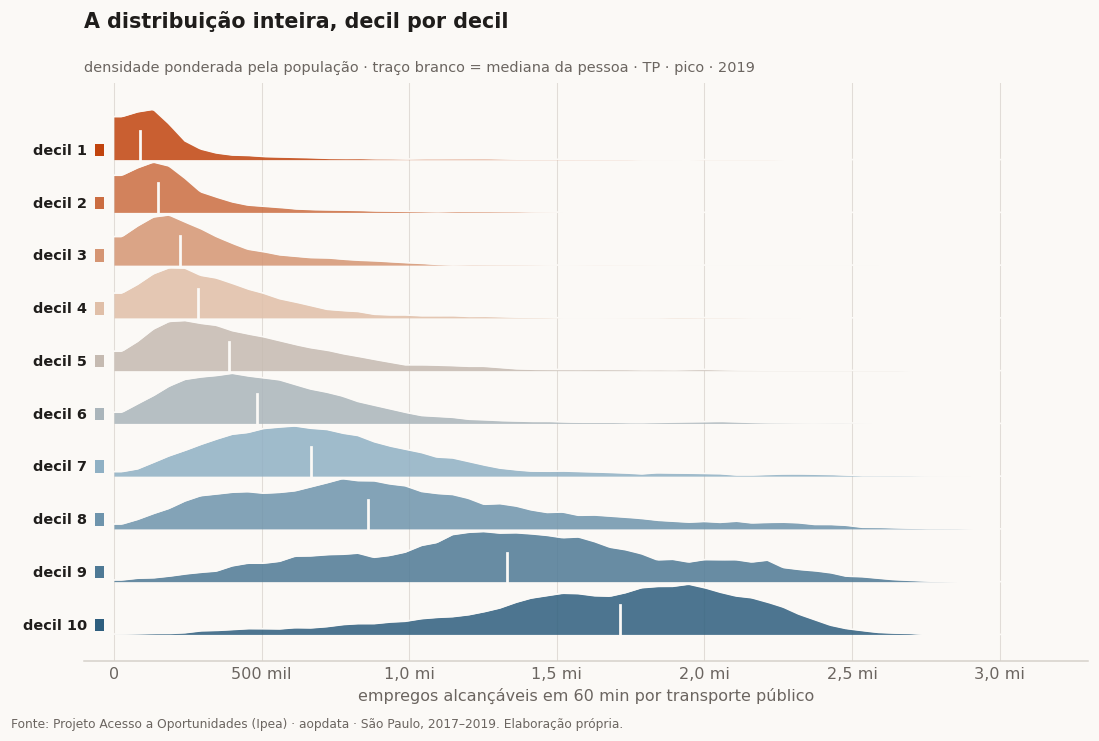

In [22]:
fig, ax = plt.subplots(figsize=(10, 6.6))
grade = np.linspace(0, 3.2e6, 400)
passo = 1.0

for i, decil in enumerate(range(10, 0, -1)):
    d = tp19[tp19.decil_renda == decil]
    v = d.empregos_60min.values
    w = d.pop_total.values.astype(float)
    # densidade ponderada pela população (histograma suavizado)
    dens, bordas = np.histogram(v, bins=60, range=(0, 3.2e6), weights=w, density=True)
    centros = (bordas[:-1] + bordas[1:]) / 2
    suave = np.interp(grade, centros, np.convolve(dens, np.ones(5) / 5, mode="same"))
    suave = suave / suave.max() * 0.95
    base = i * passo
    cor = cmap_decil((decil - 1) / 9)
    ax.fill_between(grade, base, base + suave, color=cor, alpha=0.85, lw=0)
    ax.plot(grade, base + suave, color=PAPEL, lw=1.1)
    mediana = quantil_pond(d.empregos_60min, d.pop_total, 0.5)
    ax.plot([mediana, mediana], [base, base + 0.55], color=PAPEL, lw=1.8, zorder=5)
    ax.text(-9e4, base + 0.18, f"decil {decil}", ha="right", va="center",
            fontsize=9.5, color=TINTA, fontweight="bold")
    ax.add_patch(plt.Rectangle((-6.5e4, base + 0.06), 3.2e4, 0.24, color=cor,
                               clip_on=False, lw=0))

ax.set_yticks([])
ax.set_xlim(-1.0e5, 3.3e6)
ax.set_xlabel("empregos alcançáveis em 60 min por transporte público")
ax.xaxis.set_major_formatter(EIXO_MIL)
ax.spines["left"].set_visible(False)
ax.grid(axis="y", visible=False)
titular(ax, "A distribuição inteira, decil por decil",
        "densidade ponderada pela população · traço branco = mediana da pessoa · TP · pico · 2019")
rodape(fig, FONTE)
plt.tight_layout(); plt.show()

## Passo 4.6 — Que tipo de emprego cada decil alcança

Não basta contar empregos: importa se são empregos **compatíveis** com a
escolaridade de quem mora ali. A base traz o alcance separado por exigência de
escolaridade, o que permite testar a hipótese de *mismatch*.

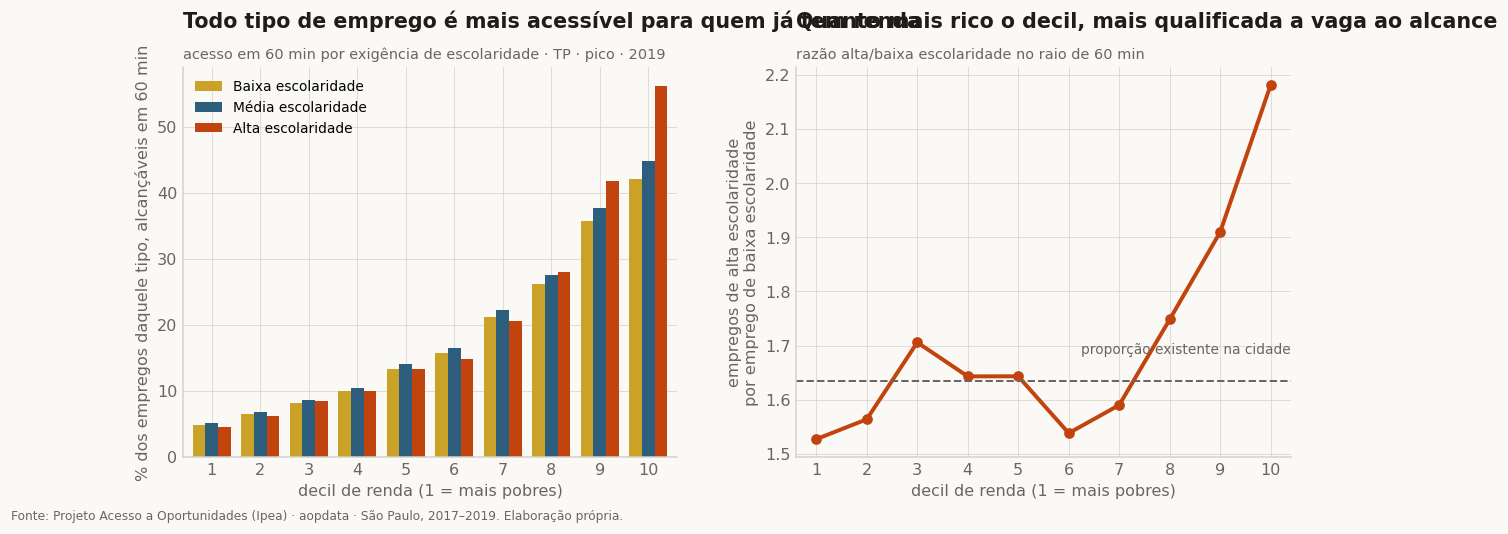

,baixa,media,alta,razao_alta_baixa
decil_renda,,,,
1.00,"29,207.00","95,960.00","44,603.00",1.53
2.00,"39,067.00","128,460.00","61,096.00",1.56
3.00,"48,742.00","162,757.00","83,150.00",1.71
4.00,"59,385.00","198,089.00","97,578.00",1.64
5.00,"79,624.00","264,525.00","130,842.00",1.64
6.00,"94,358.00","312,404.00","145,144.00",1.54
7.00,"126,542.00","420,001.00","201,217.00",1.59
8.00,"156,474.00","521,305.00","273,565.00",1.75
9.00,"213,668.00","713,462.00","408,075.00",1.91


In [23]:
esc = (tp19.dropna(subset=["decil_renda"]).groupby("decil_renda")
       .apply(lambda d: pd.Series({
           "baixa": pond(d.empregos_baixa_esc_60min, d.pop_total),
           "media": pond(d.empregos_media_esc_60min, d.pop_total),
           "alta": pond(d.empregos_alta_esc_60min, d.pop_total),
       }), include_groups=False))
oferta = uso19[["empregos_baixa_esc", "empregos_media_esc", "empregos_alta_esc"]].sum()
esc_pct = esc.div(oferta.values, axis=1) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"wspace": 0.24})

ax = axes[0]
larg = 0.26
for k, (col, rot, cor) in enumerate([("baixa", "Baixa escolaridade", AREIA),
                                     ("media", "Média escolaridade", APOIO),
                                     ("alta", "Alta escolaridade", DESTAQUE)]):
    ax.bar(esc_pct.index + (k - 1) * larg, esc_pct[col], width=larg, color=cor, label=rot)
ax.set_xticks(range(1, 11)); ax.set_xlim(0.4, 10.6)
ax.set_xlabel("decil de renda (1 = mais pobres)")
ax.set_ylabel("% dos empregos daquele tipo, alcançáveis em 60 min")
ax.legend(fontsize=9, loc="upper left")
titular(ax, "Todo tipo de emprego é mais acessível para quem já tem renda",
        "acesso em 60 min por exigência de escolaridade · TP · pico · 2019")

ax = axes[1]
razao_esc = (esc.alta / esc.baixa)
ax.plot(razao_esc.index, razao_esc.values, color=DESTAQUE, lw=2.6, marker="o", ms=6)
ax.axhline(oferta.empregos_alta_esc / oferta.empregos_baixa_esc, color=GRAFITE,
           lw=1.3, ls="--")
ax.text(10.4, oferta.empregos_alta_esc / oferta.empregos_baixa_esc + 0.05,
        "proporção existente na cidade", ha="right", fontsize=9, color=GRAFITE)
ax.set_xticks(range(1, 11)); ax.set_xlim(0.6, 10.4)
ax.set_xlabel("decil de renda (1 = mais pobres)")
ax.set_ylabel("empregos de alta escolaridade\npor emprego de baixa escolaridade")
titular(ax, "Quanto mais rico o decil, mais qualificada a vaga ao alcance",
        "razão alta/baixa escolaridade no raio de 60 min")

rodape(fig, FONTE)
plt.tight_layout(); plt.show()

esc.round(0).assign(razao_alta_baixa=razao_esc.round(2))

> **Achado 10 — não há compensação por tipo de vaga.** Poderia acontecer de a
> periferia alcançar poucos empregos, mas proporcionalmente mais empregos de
> baixa escolaridade — algo como um mercado local compatível. Não é o caso: a
> penalização atinge as três faixas, e a razão alta/baixa sobe monotonicamente
> com o decil. Quem está no decil 1 tem menos vagas ao alcance **e** um mix
> menos qualificado do que a média da cidade.

## Passo 4.7 — Pico contra fora-pico: a hora em que se vai trabalhar

O commute acontece no pico. Se o pico for pior que o fora-pico, a medida usual
de acessibilidade **subestima** o problema. Comparamos os dois períodos no
mesmo hexágono — um gráfico de haltere (*dumbbell*), que mostra o par e a
distância entre eles.

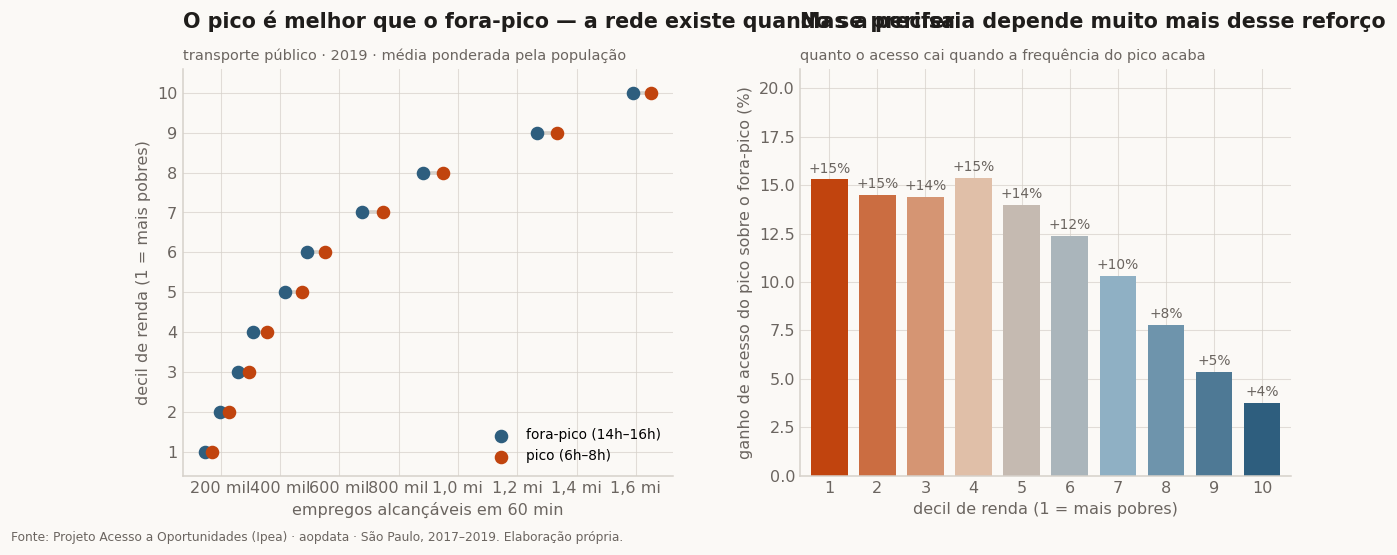

periodo,fora_pico,pico,ganho_%
decil_renda,,,
1.00,"147,236.50","169,770.80",15.30
2.00,"199,663.10","228,623.90",14.50
3.00,"257,578.80","294,648.70",14.40
4.00,"307,711.80","355,051.20",15.40
5.00,"416,657.30","474,991.60",14.00
6.00,"491,148.60","551,905.80",12.40
7.00,"677,817.30","747,759.90",10.30
8.00,"882,704.60","951,344.70",7.80
9.00,"1,267,353.90","1,335,205.60",5.40


In [24]:
per = (tp[tp.ano == 2019].dropna(subset=["decil_renda"])
       .groupby(["decil_renda", "periodo"])
       .apply(lambda d: pond(d.empregos_60min, d.pop_total), include_groups=False)
       .unstack())
per["ganho_%"] = (per.pico - per.fora_pico) / per.fora_pico * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"wspace": 0.26})

ax = axes[0]
for decil in per.index:
    ax.plot([per.loc[decil, "fora_pico"], per.loc[decil, "pico"]], [decil, decil],
            color=NEVOA, lw=2.4, zorder=1, solid_capstyle="round")
ax.scatter(per.fora_pico, per.index, s=62, color=APOIO, zorder=3, label="fora-pico (14h–16h)")
ax.scatter(per.pico, per.index, s=62, color=DESTAQUE, zorder=3, label="pico (6h–8h)")
ax.set_yticks(range(1, 11)); ax.set_ylim(0.4, 10.6)
ax.set_ylabel("decil de renda (1 = mais pobres)")
ax.set_xlabel("empregos alcançáveis em 60 min")
ax.xaxis.set_major_formatter(EIXO_MIL)
ax.legend(loc="lower right", fontsize=9)
titular(ax, "O pico é melhor que o fora-pico — a rede existe quando se precisa",
        "transporte público · 2019 · média ponderada pela população")

ax = axes[1]
cores_g = [cmap_decil((v - 1) / 9) for v in per.index]
ax.bar(per.index, per["ganho_%"], color=cores_g, width=0.76)
for x, v in zip(per.index, per["ganho_%"]):
    ax.text(x, v + 0.35, f"+{v:.0f}%", ha="center", fontsize=9, color=GRAFITE)
ax.set_xticks(range(1, 11)); ax.set_xlim(0.4, 10.6); ax.set_ylim(0, 21)
ax.set_xlabel("decil de renda (1 = mais pobres)")
ax.set_ylabel("ganho de acesso do pico sobre o fora-pico (%)")
titular(ax, "Mas a periferia depende muito mais desse reforço",
        "quanto o acesso cai quando a frequência do pico acaba")

rodape(fig, FONTE)
plt.tight_layout(); plt.show()

per.round(1)

> **Achado 11 — a periferia é a que mais depende do reforço de frequência do
> pico.** O decil 1 ganha 15% de acesso no pico em relação ao fora-pico; o decil
> 10, apenas 5%. A leitura: no centro rico a rede é **densa o bastante para não
> depender de horário**; na periferia o acesso é feito de linhas que só existem
> com frequência de pico. Fora dele — trabalho noturno, turno, plantão,
> informalidade — a periferia perde primeiro. Isso é uma hipótese de causa
> concreta para investigar com o GTFS na fase de modelagem.

## Passo 4.8 — 2017 a 2019: alguma coisa melhorou?

O slide "investimentos sem resultado real" precisa de teste. Três anos é uma
janela curta, mas é o que a base cobre.

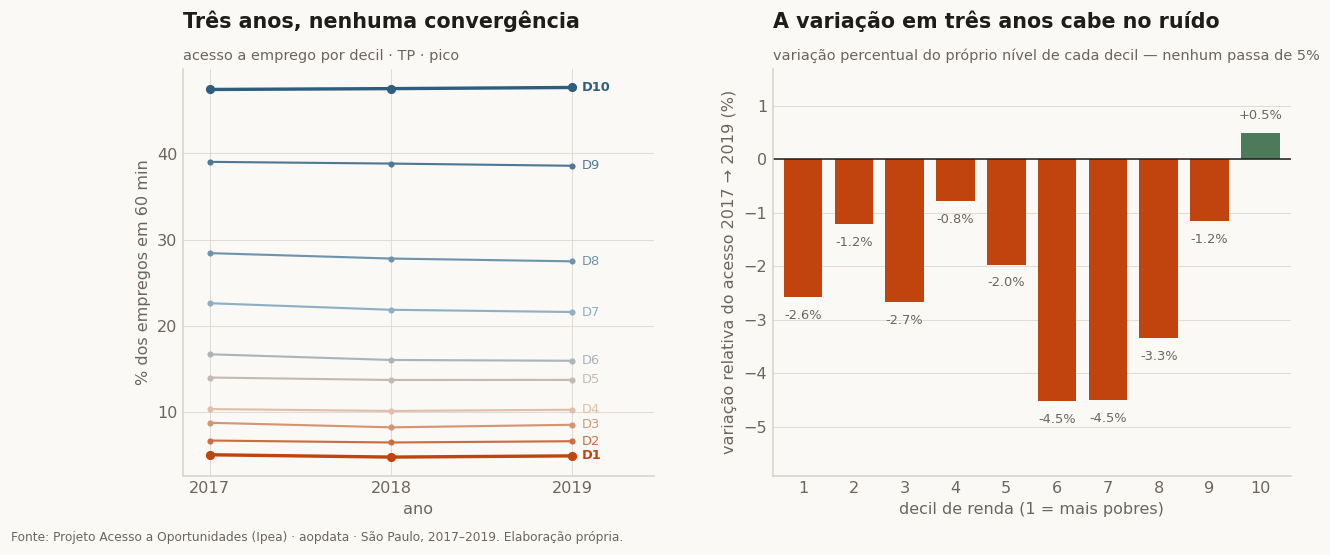

,cidade (%),decil 1 (%),decil 10 (%),razão D10/D1
ano,,,,
2017,19.90,5.03,47.42,9.42
2018,19.53,4.76,47.52,9.97
2019,19.52,4.90,47.65,9.72


In [25]:
serie = (tp[tp.periodo == "pico"].dropna(subset=["decil_renda"])
         .groupby(["ano", "decil_renda"])
         .apply(lambda d: pond(d.pct_empregos_60, d.pop_total), include_groups=False)
         .unstack())
serie_cidade = (tp[tp.periodo == "pico"].groupby("ano")
                .apply(lambda d: pond(d.pct_empregos_60, d.pop_total), include_groups=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"wspace": 0.24, "width_ratios": [1, 1.1]})

ax = axes[0]
for decil in serie.columns:
    cor = cmap_decil((decil - 1) / 9)
    ax.plot(serie.index, serie[decil], color=cor, lw=2.2 if decil in (1, 10) else 1.4,
            marker="o", ms=5 if decil in (1, 10) else 3)
    ax.annotate(f"D{int(decil)}", xy=(2019, serie.loc[2019, decil]), xytext=(6, 0),
                textcoords="offset points", va="center", fontsize=8.5, color=cor,
                fontweight="bold" if decil in (1, 10) else "normal")
ax.set_xticks([2017, 2018, 2019]); ax.set_xlim(2016.85, 2019.45)
ax.set_xlabel("ano"); ax.set_ylabel("% dos empregos em 60 min")
titular(ax, "Três anos, nenhuma convergência",
        "acesso a emprego por decil · TP · pico")

ax = axes[1]
variacao = ((serie.loc[2019] - serie.loc[2017]) / serie.loc[2017] * 100)
cores_v = [DESTAQUE if v < 0 else VERDE for v in variacao]
ax.bar(variacao.index, variacao.values, color=cores_v, width=0.76)
for x, v in zip(variacao.index, variacao.values):
    ax.text(x, v + (0.22 if v >= 0 else -0.22), f"{v:+.1f}%", ha="center",
            fontsize=8.5, color=GRAFITE, va="bottom" if v >= 0 else "top")
ax.axhline(0, color=TINTA, lw=1.0)
ax.set_xticks(range(1, 11)); ax.set_xlim(0.4, 10.6)
ax.set_ylim(variacao.min() - 1.4, variacao.max() + 1.2)
ax.set_xlabel("decil de renda (1 = mais pobres)")
ax.set_ylabel("variação relativa do acesso 2017 → 2019 (%)")
ax.grid(axis="x", visible=False)
titular(ax, "A variação em três anos cabe no ruído",
        "variação percentual do próprio nível de cada decil — nenhum passa de 5%")

rodape(fig, FONTE)
plt.tight_layout(); plt.show()

pd.DataFrame({"cidade (%)": serie_cidade.round(2),
              "decil 1 (%)": serie[1].round(2),
              "decil 10 (%)": serie[10].round(2),
              "razão D10/D1": (serie[10] / serie[1]).round(2)})

> **Achado 12 — o acesso da cidade não se move e a razão D10/D1 não cai.** Em
> três anos o acesso médio ficou entre 19,5% e 19,9%, e a razão entre o decil
> 10 e o decil 1 permaneceu praticamente constante. As variações por decil são
> **relativas ao próprio nível** e ficam todas abaixo de 5% — e são
> majoritariamente negativas, ou seja, o pouco que se moveu, moveu para trás. Confirma a leitura da V1:
> **o problema é estrutural, não conjuntural.** Uma janela de três anos não
> prova estagnação de longo prazo, mas mostra que nada nesse período moveu o
> indicador — e a base congela a demografia, então a estabilidade não é efeito
> de composição.

---

# 5 · Tempo até o mais próximo — o que a periferia alcança a pé

As colunas `tempo_*` medem outra coisa: **minutos até o equipamento mais
próximo**, e não quantos se alcança. É a métrica certa para serviços em que
"um perto" resolve — escola, posto de saúde, CRAS.

Isso é o contraponto que fecha o argumento: se os equipamentos de bairro estão
a poucos minutos a pé mas o emprego exige uma hora de ônibus, o problema não é
capilaridade de serviço — é **localização de emprego**.

**Lembrete:** vazio aqui significa *não alcançável dentro do limite de
roteamento do modo* (60 min a pé, 90 de bicicleta, ~175 no TP). Tratamos o
vazio como categoria própria, nunca como valor a imputar.

## Passo 5.1 — A pé: o que está perto e o que não está

Histogramas empilhados verticalmente com a mesma escala de eixo x, para o olho
comparar as posições. A barra cinza à direita é a população que **não alcança**
o equipamento em uma hora de caminhada.

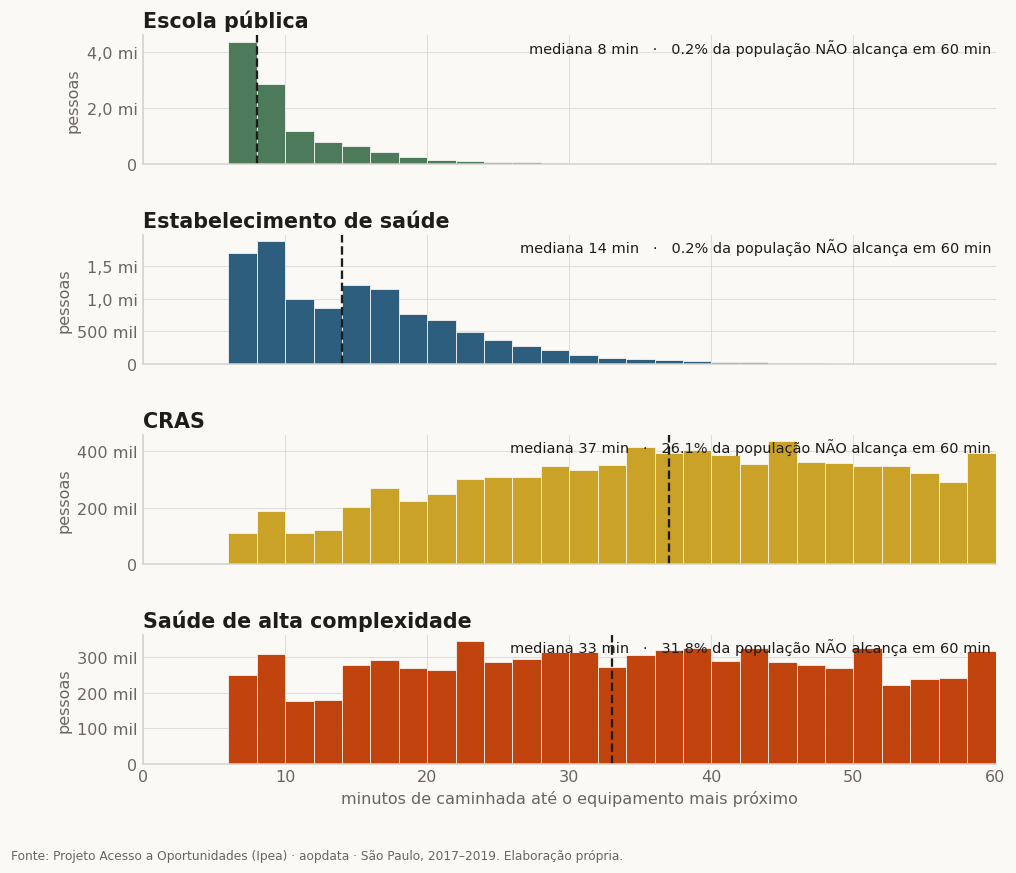

In [26]:
cam19 = hab[(hab.modo == "caminhada") & (hab.ano == 2019)]

equip = [("tempo_escola_qualquer", "Escola pública", VERDE),
         ("tempo_saude_qualquer", "Estabelecimento de saúde", APOIO),
         ("tempo_cras", "CRAS", AREIA),
         ("tempo_saude_alta_compl", "Saúde de alta complexidade", DESTAQUE)]

fig, axes = plt.subplots(len(equip), 1, figsize=(10, 8.6), sharex=True,
                         gridspec_kw={"hspace": 0.55})
for ax, (col, rot, cor) in zip(axes, equip):
    v = cam19[col]
    peso = cam19.pop_total
    ax.hist(v.dropna(), bins=np.arange(0, 62, 2), weights=peso[v.notna()],
            color=cor, edgecolor=PAPEL, linewidth=0.5)
    med = quantil_pond(v, peso, 0.5)
    ax.axvline(med, color=TINTA, lw=1.5, ls="--")
    fora = peso[v.isna()].sum() / peso.sum() * 100
    ax.text(0.995, 0.86, f"mediana {med:.0f} min   ·   {fora:.1f}% da população NÃO alcança em 60 min",
            transform=ax.transAxes, ha="right", fontsize=9.5, color=TINTA)
    ax.set_ylabel("pessoas")
    ax.yaxis.set_major_formatter(EIXO_MIL)
    titular(ax, rot)
axes[-1].set_xlabel("minutos de caminhada até o equipamento mais próximo")
axes[-1].set_xlim(0, 60)
rodape(fig, FONTE, y=0.02)
plt.tight_layout(); plt.show()

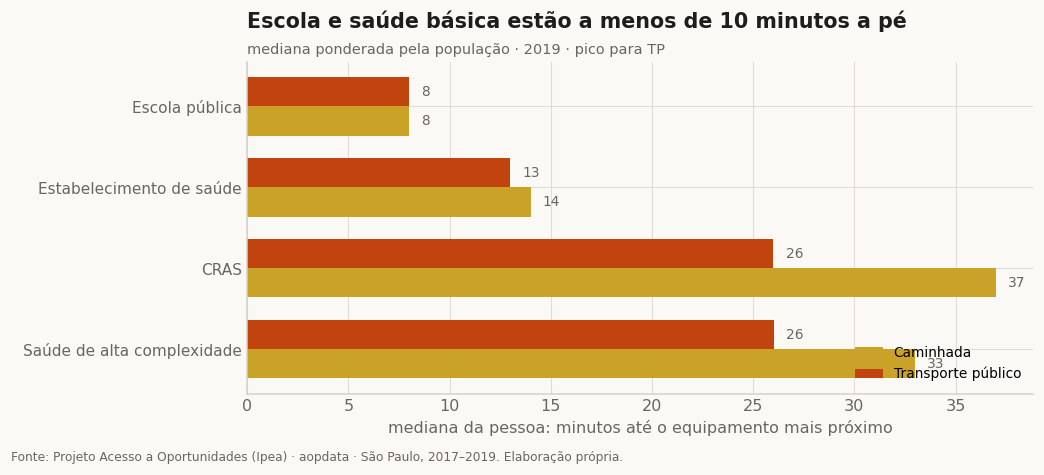

,modo,equipamento,mediana_min,pop_sem_alcance_%
0,caminhada,Escola pública,8.00,0.20
1,caminhada,Estabelecimento de saúde,14.00,0.20
2,caminhada,CRAS,37.00,26.10
3,caminhada,Saúde de alta complexidade,33.00,31.80
4,transporte_publico,Escola pública,8.00,0.10
5,transporte_publico,Estabelecimento de saúde,13.00,0.10
6,transporte_publico,CRAS,26.00,0.10
7,transporte_publico,Saúde de alta complexidade,26.00,0.10


In [27]:
# a mesma pergunta, agora comparando caminhada e transporte público
comp = []
for modo in ["caminhada", "transporte_publico"]:
    d = hab[(hab.modo == modo) & (hab.ano == 2019)]
    d = d[d.periodo != "fora_pico"]
    for col, rot, _ in equip:
        comp.append({"modo": modo, "equipamento": rot,
                     "mediana_min": quantil_pond(d[col], d.pop_total, 0.5),
                     "pop_sem_alcance_%": d.pop_total[d[col].isna()].sum() / d.pop_total.sum() * 100})
comp = pd.DataFrame(comp)

fig, ax = plt.subplots(figsize=(9.5, 4.2))
larg, y = 0.36, np.arange(len(equip))
for k, (modo, cor) in enumerate([("caminhada", AREIA), ("transporte_publico", DESTAQUE)]):
    d = comp[comp.modo == modo].set_index("equipamento").loc[[r for _, r, _ in equip]]
    ax.barh(y + (0.5 - k) * larg, d.mediana_min, height=larg, color=cor,
            label=ROTULO_MODO[modo])
    for yi, v in zip(y + (0.5 - k) * larg, d.mediana_min):
        ax.text(v + 0.6, yi, f"{v:.0f}", va="center", fontsize=9, color=GRAFITE)
ax.set_yticks(y, [r for _, r, _ in equip], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("mediana da pessoa: minutos até o equipamento mais próximo")
ax.legend(loc="lower right", fontsize=9)
titular(ax, "Escola e saúde básica estão a menos de 10 minutos a pé",
        "mediana ponderada pela população · 2019 · pico para TP")
rodape(fig, FONTE)
plt.tight_layout(); plt.show()

comp.round(1)

> **Achado 13 — a cidade resolveu o equipamento de bairro e não resolveu o
> emprego.** A mediana de caminhada até a escola pública mais próxima é de
> **8 minutos**, e até um estabelecimento de saúde, **14**. Mas 32% da
> população não alcança **saúde de alta complexidade** em uma hora a pé, e 26%
> não alcança um **CRAS** — as duas únicas categorias em que a caminhada falha
> em massa, e as duas em que o destino é centralizado.
>
> Isso reforça o problem statement por um caminho novo: o que é local está
> resolvido; o que é **centralizado** — o hospital de referência e, sobretudo,
> o emprego — depende inteiramente de um transporte público que entrega 19,5%
> da cidade em uma hora.

## Passo 5.2 — O mapa do que falta

Onde estão as pessoas que não alcançam saúde de alta complexidade a pé, e
quanto tempo elas gastam de ônibus para chegar lá.

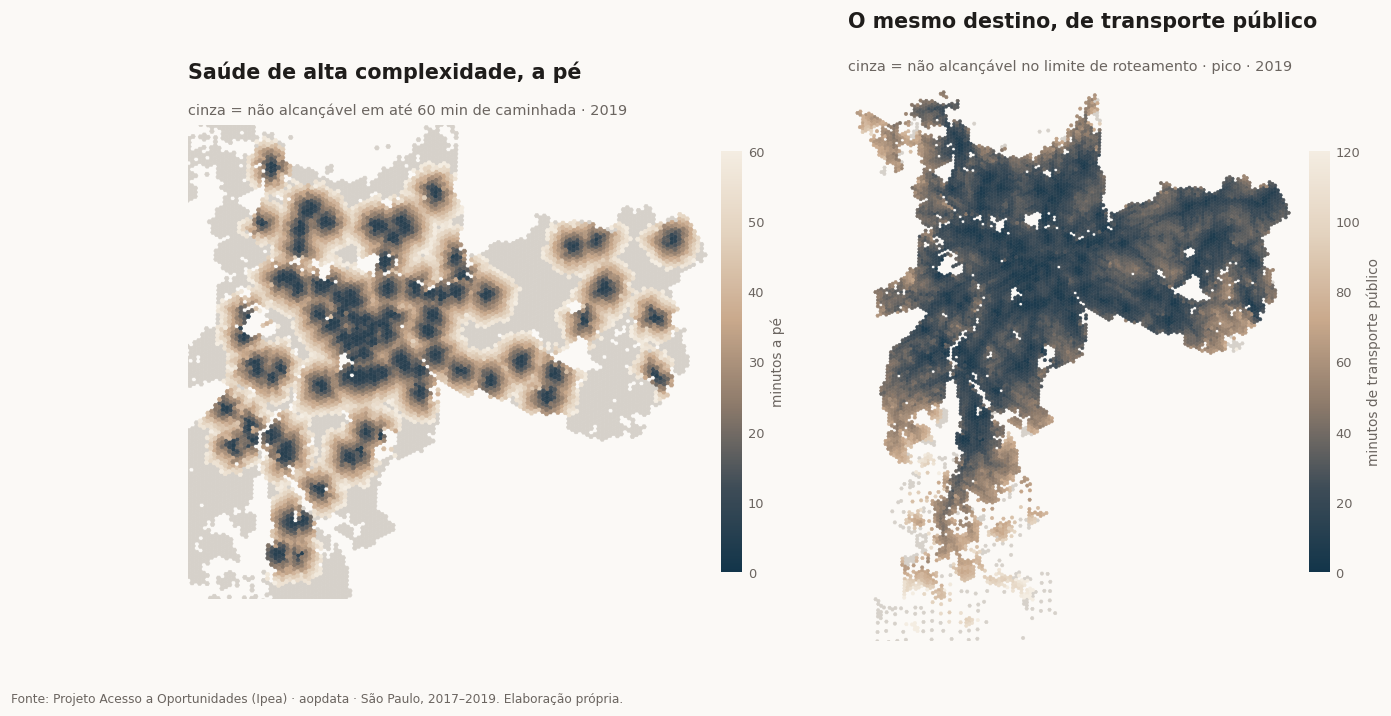

In [28]:
tps19 = tp19.copy()
fig, axes = plt.subplots(1, 2, figsize=(13.4, 6.6), gridspec_kw={"wspace": 0.06})

cam_map = cam19.copy()
mapa_hex(axes[0], cam_map, "tempo_saude_alta_compl", vmin=0, vmax=60, cmap=SEQ.reversed(),
         fmt=None, rotulo_escala="minutos a pé",
         titulo="Saúde de alta complexidade, a pé",
         subtitulo="cinza = não alcançável em até 60 min de caminhada · 2019")

mapa_hex(axes[1], tps19, "tempo_saude_alta_compl", vmin=0, vmax=120, cmap=SEQ.reversed(),
         fmt=None, rotulo_escala="minutos de transporte público",
         titulo="O mesmo destino, de transporte público",
         subtitulo="cinza = não alcançável no limite de roteamento · pico · 2019")

rodape(fig, FONTE, y=0.04)
plt.show()

## Passo 5.3 — Tempo por decil: um mapa de calor de todos os destinos

Um único painel resume a Parte 5. Linhas são equipamentos, colunas são decis; a
cor é o tempo mediano da pessoa. Uma faixa horizontal uniforme significa
"equipamento distribuído"; um gradiente da esquerda para a direita significa
"privilégio".

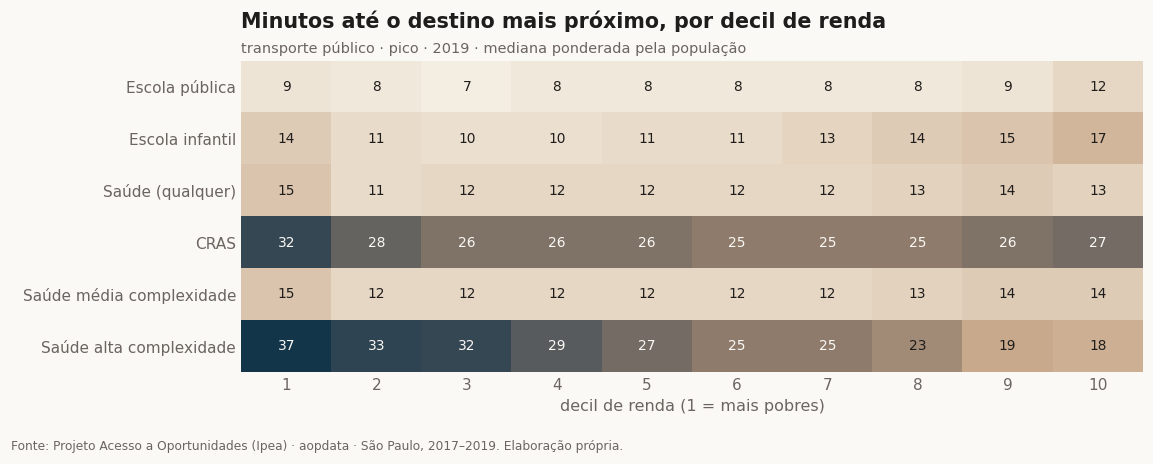

decil_renda,1.00,2.00,3.00,4.00,5.00,6.00,7.00,8.00,9.00,10.00
Escola pública,9.00,8.00,7.00,8.00,8.00,8.00,8.00,8.00,9.00,12.00
Escola infantil,14.00,11.00,10.00,10.00,11.00,11.00,12.60,14.00,15.00,17.00
Saúde (qualquer),15.00,11.00,12.00,12.00,12.00,12.00,12.00,13.00,14.00,13.00
CRAS,32.00,28.00,26.00,26.00,26.00,25.00,25.00,25.00,26.00,27.00
Saúde média complexidade,15.00,12.00,12.00,12.00,12.00,12.00,12.00,13.00,14.00,14.00
Saúde alta complexidade,37.00,33.00,32.00,29.00,27.00,25.00,25.00,23.00,19.00,18.00


In [29]:
alvos_tempo = [("tempo_escola_qualquer", "Escola pública"),
               ("tempo_escola_infantil", "Escola infantil"),
               ("tempo_saude_qualquer", "Saúde (qualquer)"),
               ("tempo_cras", "CRAS"),
               ("tempo_saude_media_compl", "Saúde média complexidade"),
               ("tempo_saude_alta_compl", "Saúde alta complexidade")]

calor = pd.DataFrame({
    rot: tp19.dropna(subset=["decil_renda"]).groupby("decil_renda")
           .apply(lambda d: quantil_pond(d[col], d.pop_total, 0.5), include_groups=False)
    for col, rot in alvos_tempo}).T

fig, ax = plt.subplots(figsize=(10.5, 4))
im = ax.imshow(calor.values, cmap=SEQ, aspect="auto")
ax.set_xticks(range(10), [int(c) for c in calor.columns], fontsize=10)
ax.set_yticks(range(len(calor)), calor.index, fontsize=10)
ax.set_xlabel("decil de renda (1 = mais pobres)")
for i in range(calor.shape[0]):
    for j in range(calor.shape[1]):
        v = calor.values[i, j]
        limiar = np.nanmin(calor.values) + 0.55 * np.ptp(calor.values)
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=9,
                color=PAPEL if v > limiar else TINTA)
titular(ax, "Minutos até o destino mais próximo, por decil de renda",
        "transporte público · pico · 2019 · mediana ponderada pela população")
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
rodape(fig, FONTE, y=-0.02)
plt.tight_layout(); plt.show()

calor.round(1)

> **Achado 14 — o gradiente de renda existe na saúde e some na escola.** O
> tempo mediano até saúde de alta complexidade cai de 37 min (decil 1) para 18
> min (decil 10) — mais que o dobro. Já o tempo até a escola pública é
> praticamente plano (7 a 9 min do decil 1 ao decil 9) e no decil 10 chega a
> ser **pior** (12 min),
> porque escola pública é mais rara em bairro rico. É a evidência mais limpa de
> que a desigualdade da base não é um artefato de "periferia = tudo longe": ela
> aparece só onde o destino é **centralizado**.

---

# 6 · Relações e anomalias

## Passo 6.1 — Renda contra acesso, hexágono a hexágono

O scatter de 9.704 pontos vira uma mancha ilegível. Usamos densidade hexagonal
(*hexbin*) para mostrar onde a massa está, com a média ponderada por faixa de
renda por cima.

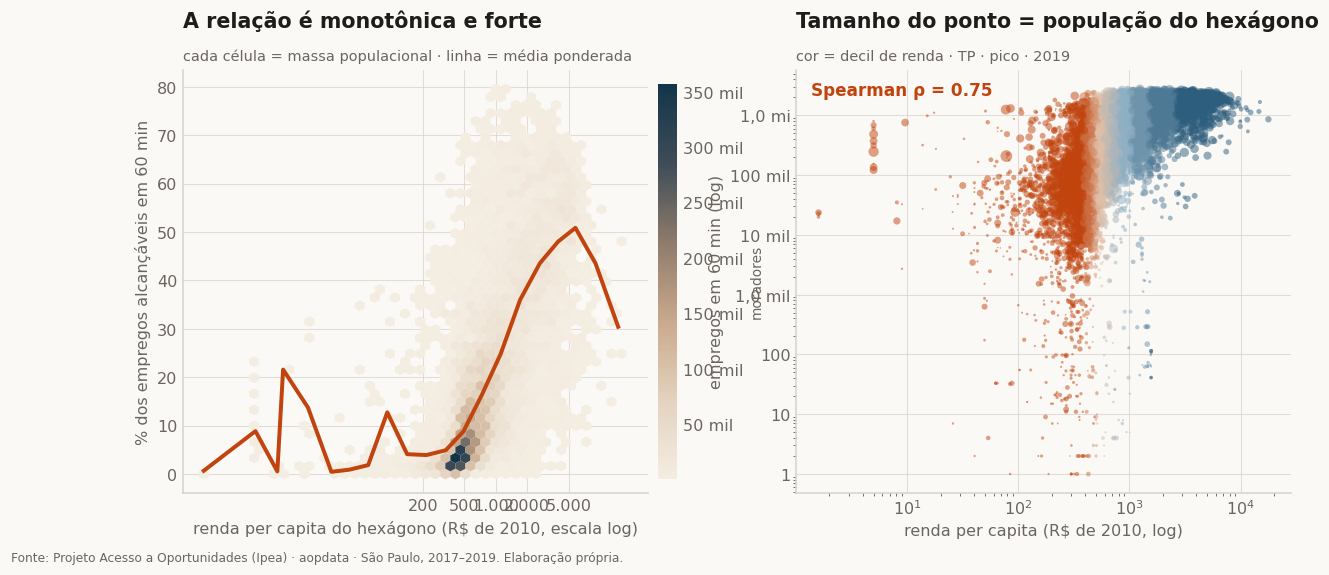

In [30]:
d = tp19.dropna(subset=["renda_per_capita"])
d = d[d.renda_per_capita > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"wspace": 0.24})

ax = axes[0]
hb = ax.hexbin(np.log10(d.renda_per_capita), d.pct_empregos_60, gridsize=42,
               C=d.pop_total, reduce_C_function=np.sum, cmap=SEQ, mincnt=1, linewidths=0)
cb = fig.colorbar(hb, ax=ax, fraction=0.04, pad=0.02)
cb.set_label("moradores", color=GRAFITE, fontsize=9)
cb.outline.set_visible(False)
cb.ax.yaxis.set_major_formatter(EIXO_MIL)
faixas = pd.cut(np.log10(d.renda_per_capita), bins=22)
linha = d.groupby(faixas, observed=True).apply(
    lambda g: pd.Series({"x": np.log10(g.renda_per_capita).mean(),
                         "y": pond(g.pct_empregos_60, g.pop_total)}), include_groups=False)
ax.plot(linha.x, linha.y, color=DESTAQUE, lw=2.6)
ticks = [200, 500, 1000, 2000, 5000]
ax.set_xticks(np.log10(ticks), [br(t) for t in ticks])
ax.set_xlabel("renda per capita do hexágono (R$ de 2010, escala log)")
ax.set_ylabel("% dos empregos alcançáveis em 60 min")
titular(ax, "A relação é monotônica e forte",
        "cada célula = massa populacional · linha = média ponderada")

ax = axes[1]
corr = d[["renda_per_capita", "pct_empregos_60"]].corr(method="spearman").iloc[0, 1]
ax.scatter(d.renda_per_capita, d.empregos_60min, s=np.sqrt(d.pop_total) * 0.9,
           c=[cmap_decil((v - 1) / 9) for v in d.decil_renda], alpha=0.5, linewidths=0)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("renda per capita (R$ de 2010, log)")
ax.set_ylabel("empregos em 60 min (log)")
ax.yaxis.set_major_formatter(EIXO_MIL)
ax.text(0.03, 0.94, f"Spearman ρ = {corr:.2f}", transform=ax.transAxes,
        fontsize=11, fontweight="bold", color=DESTAQUE)
titular(ax, "Tamanho do ponto = população do hexágono",
        "cor = decil de renda · TP · pico · 2019")

rodape(fig, FONTE)
plt.tight_layout(); plt.show()

## Passo 6.2 — O que anda junto com o quê

Matriz de correlação de Spearman entre as variáveis candidatas a *feature*.
Serve para dois fins: identificar redundância (cortes de tempo quase colineares)
e confirmar que renda e acesso não são a mesma variável.

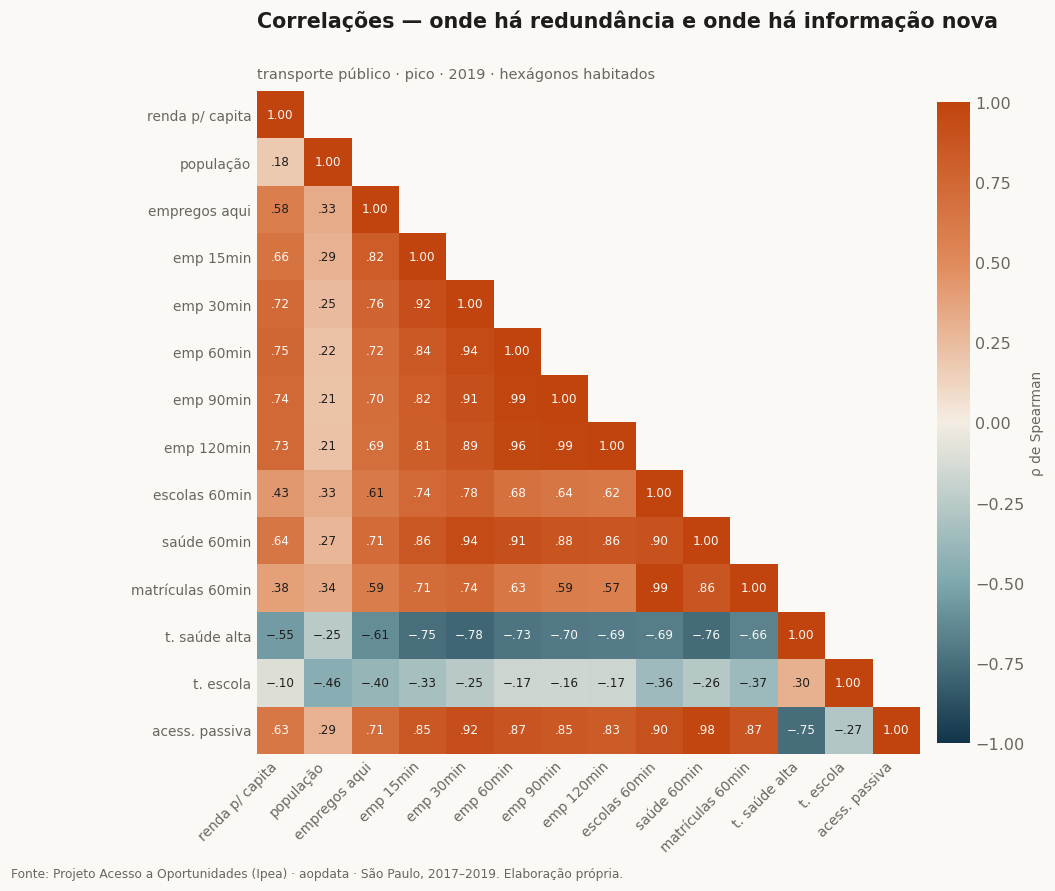

In [31]:
vars_corr = ["renda_per_capita", "pop_total", "empregos_total",
             "empregos_15min", "empregos_30min", "empregos_60min",
             "empregos_90min", "empregos_120min",
             "escolas_60min", "saude_60min", "matriculas_60min",
             "tempo_saude_alta_compl", "tempo_escola_qualquer",
             "pessoas_que_alcancam_60min"]
ROT = {"renda_per_capita": "renda p/ capita", "pop_total": "população",
       "empregos_total": "empregos aqui", "empregos_15min": "emp 15min",
       "empregos_30min": "emp 30min", "empregos_60min": "emp 60min",
       "empregos_90min": "emp 90min", "empregos_120min": "emp 120min",
       "escolas_60min": "escolas 60min", "saude_60min": "saúde 60min",
       "matriculas_60min": "matrículas 60min",
       "tempo_saude_alta_compl": "t. saúde alta", "tempo_escola_qualquer": "t. escola",
       "pessoas_que_alcancam_60min": "acess. passiva"}

C = tp19[vars_corr].corr(method="spearman")
mask = np.triu(np.ones_like(C, dtype=bool), k=1)
Cm = np.where(mask, np.nan, C.values)

fig, ax = plt.subplots(figsize=(9.6, 8))
im = ax.imshow(Cm, cmap=DIV, vmin=-1, vmax=1)
ax.set_xticks(range(len(C)), [ROT[c] for c in C.columns], rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(C)), [ROT[c] for c in C.index], fontsize=9)
for i in range(len(C)):
    for j in range(i + 1):
        v = C.values[i, j]
        ax.text(j, i, f"{v:.2f}".replace("0.", ".").replace("-.", "−."),
                ha="center", va="center", fontsize=7.8,
                color=PAPEL if abs(v) > 0.62 else TINTA)
cb = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cb.set_label("ρ de Spearman", color=GRAFITE, fontsize=9)
cb.outline.set_visible(False)
titular(ax, "Correlações — onde há redundância e onde há informação nova",
        "transporte público · pico · 2019 · hexágonos habitados")
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
rodape(fig, FONTE, y=0.005)
plt.tight_layout(); plt.show()

> **Achado 15 — os cortes de tempo são quase redundantes entre si, mas não
> completamente.** `empregos_30min` e `empregos_60min` andam muito juntos;
> `empregos_120min` já se descola. Para a modelagem, isso significa que **não
> precisamos das seis colunas de corte** — precisamos de uma (60 min, o padrão
> da literatura) mais uma medida de *forma* da curva, que é justamente a razão
> entre cortes. Registramos a sugestão na Parte 7.
>
> Note também que `renda_per_capita` e `empregos_60min` correlacionam forte mas
> longe de 1: **acesso não é um proxy de renda.** Há hexágonos pobres com bom
> acesso e ricos com acesso ruim — e é neles que está a informação útil.

## Passo 6.3 — Os fora-da-curva: onde o modelo mental falha

Os hexágonos que fogem da relação renda × acesso são os casos que merecem
inspeção qualitativa — e são os melhores candidatos a estudo de caso na
apresentação.

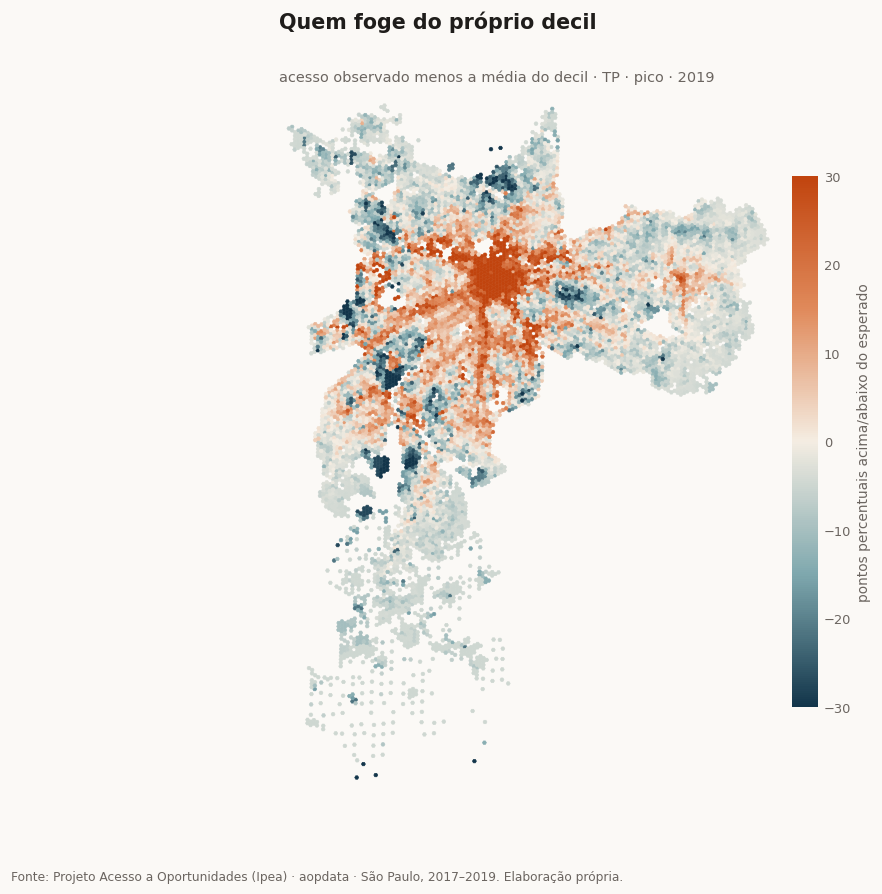

Decis 1–3 com acesso MUITO acima do esperado (candidatos a caso de sucesso):


,id_hex,decil_renda,pop_total,pct_empregos_60,residuo,lon,lat
46591,89a8100c36fffff,1.00,1194,61.10,56.20,-46.60,-23.50
73695,89a8100f1dbffff,2.00,2743,57.90,51.30,-46.60,-23.60
74829,89a8100f38fffff,1.00,2332,46.70,41.80,-46.60,-23.60
53059,89a8100ce0bffff,3.00,706,50.00,41.50,-46.60,-23.50
74465,89a8100f317ffff,3.00,1789,48.90,40.40,-46.60,-23.60
74913,89a8100f3abffff,1.00,1023,44.00,39.10,-46.60,-23.60
62705,89a8100de57ffff,1.00,1200,40.10,35.20,-46.60,-23.50
63055,89a8100decbffff,2.00,1457,41.50,34.90,-46.60,-23.50
55817,89a8100d323ffff,2.00,636,41.20,34.60,-46.60,-23.50
58953,89a8100d8a7ffff,1.00,883,39.40,34.40,-46.60,-23.50



Decis 8–10 com acesso abaixo do esperado:


,id_hex,decil_renda,pop_total,pct_empregos_60,residuo,lon,lat
22847,89a81005837ffff,10.00,513,1.40,-46.20,-46.80,-23.60
25815,89a81005dd3ffff,10.00,974,6.10,-41.60,-46.80,-23.60
21895,89a810055c3ffff,10.00,1689,6.90,-40.70,-46.70,-23.60
21545,89a8100554fffff,10.00,1260,8.00,-39.70,-46.70,-23.60
24499,89a81005b9bffff,10.00,1038,9.40,-38.30,-46.80,-23.60
18381,89a81005093ffff,10.00,987,9.90,-37.70,-46.70,-23.60
132355,89a81076627ffff,10.00,818,10.30,-37.40,-46.60,-23.50
21951,89a810055d3ffff,10.00,554,10.40,-37.30,-46.70,-23.60
21979,89a810055dbffff,10.00,1116,11.10,-36.50,-46.70,-23.60
21503,89a81005543ffff,10.00,1263,11.10,-36.50,-46.70,-23.60


In [32]:
d = tp19.dropna(subset=["decil_renda"]).copy()
esperado = d.groupby("decil_renda").apply(
    lambda g: pond(g.pct_empregos_60, g.pop_total), include_groups=False)
d["residuo"] = d.pct_empregos_60 - d.decil_renda.map(esperado)

pobres_bem = (d[(d.decil_renda <= 3) & (d.pop_total > 500)]
              .nlargest(10, "residuo")[["id_hex", "decil_renda", "pop_total",
                                        "pct_empregos_60", "residuo", "lon", "lat"]])
ricos_mal = (d[(d.decil_renda >= 8) & (d.pop_total > 500)]
             .nsmallest(10, "residuo")[["id_hex", "decil_renda", "pop_total",
                                        "pct_empregos_60", "residuo", "lon", "lat"]])

fig, ax = plt.subplots(figsize=(8.2, 8.2))
mapa_hex(ax, d, "residuo", cmap=DIV, norm=TwoSlopeNorm(vcenter=0, vmin=-30, vmax=30),
         fmt=None, rotulo_escala="pontos percentuais acima/abaixo do esperado",
         titulo="Quem foge do próprio decil",
         subtitulo="acesso observado menos a média do decil · TP · pico · 2019")
rodape(fig, FONTE, y=0.02)
plt.show()

print("Decis 1–3 com acesso MUITO acima do esperado (candidatos a caso de sucesso):")
display(pobres_bem.round(1))
print("\nDecis 8–10 com acesso abaixo do esperado:")
display(ricos_mal.round(1))

> **Achado 16 — os positivos estão sobre os eixos de trilho.** Os hexágonos
> pobres com acesso muito acima do esperado formam um padrão reconhecível:
> estão em cima de estações da CPTM e das pontas das linhas de metrô. É a
> evidência mais direta de que **trilho muda o patamar** — e é a hipótese
> central para a fase de modelagem: o que distingue uma periferia bem servida
> de uma mal servida não é distância ao centro, é presença de modo de alta
> capacidade.

## Passo 6.4 — Acessibilidade passiva: quem chega até aqui

A base traz uma medida espelhada: `pessoas_que_alcancam_60min` — quantas
pessoas conseguem chegar **a este hexágono** em uma hora. Do ponto de vista de
um empregador, é o tamanho do mercado de trabalho disponível naquele endereço.

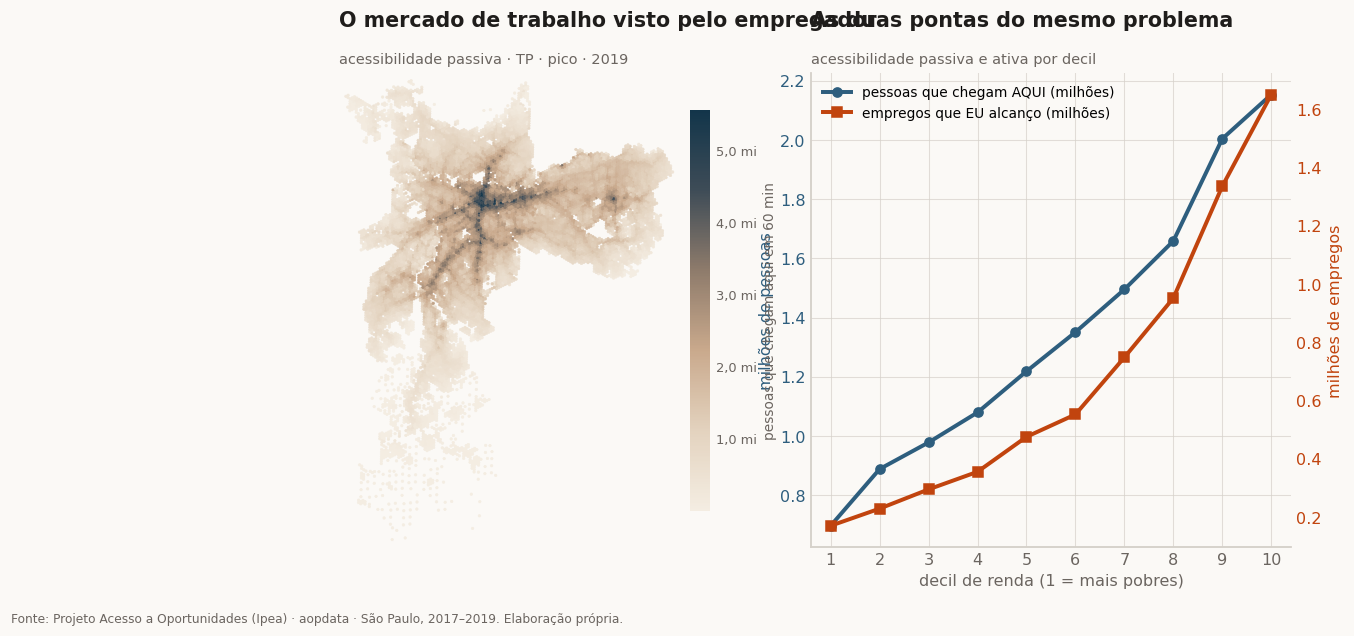

,passiva,ativa
decil_renda,,
1.00,"696,831.00","169,771.00"
2.00,"888,356.00","228,624.00"
3.00,"978,321.00","294,649.00"
4.00,"1,079,643.00","355,051.00"
5.00,"1,218,589.00","474,992.00"
6.00,"1,350,834.00","551,906.00"
7.00,"1,495,298.00","747,760.00"
8.00,"1,658,753.00","951,345.00"
9.00,"2,004,114.00","1,335,206.00"


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.6),
                         gridspec_kw={"wspace": 0.2, "width_ratios": [1.1, 1]})

mapa_hex(axes[0], tp19, "pessoas_que_alcancam_60min",
         rotulo_escala="pessoas que chegam aqui em 60 min",
         titulo="O mercado de trabalho visto pelo empregador",
         subtitulo="acessibilidade passiva · TP · pico · 2019")

ax = axes[1]
d = tp19.dropna(subset=["decil_renda"])
g = d.groupby("decil_renda").apply(
    lambda x: pd.Series({"passiva": pond(x.pessoas_que_alcancam_60min, x.pop_total),
                         "ativa": pond(x.empregos_60min, x.pop_total)}),
    include_groups=False)
ax.plot(g.index, g.passiva / 1e6, color=APOIO, lw=2.6, marker="o", ms=6,
        label="pessoas que chegam AQUI (milhões)")
ax2 = ax.twinx()
ax2.plot(g.index, g.ativa / 1e6, color=DESTAQUE, lw=2.6, marker="s", ms=6,
         label="empregos que EU alcanço (milhões)")
ax2.grid(False)
ax2.spines["top"].set_visible(False)
ax.set_xticks(range(1, 11)); ax.set_xlim(0.6, 10.4)
ax.set_xlabel("decil de renda (1 = mais pobres)")
ax.set_ylabel("milhões de pessoas", color=APOIO)
ax2.set_ylabel("milhões de empregos", color=DESTAQUE)
ax.tick_params(axis="y", colors=APOIO); ax2.tick_params(axis="y", colors=DESTAQUE)
linhas = ax.get_lines() + ax2.get_lines()
ax.legend(linhas, [l.get_label() for l in linhas], loc="upper left", fontsize=9)
titular(ax, "As duas pontas do mesmo problema",
        "acessibilidade passiva e ativa por decil")

rodape(fig, FONTE)
plt.tight_layout(); plt.show()

g.round(0)

---

# 7 · Síntese

## Os números que sustentam a próxima versão da apresentação

In [34]:
sintese = pd.DataFrame([
 ("Cobertura", "hexágonos habitados", f"{br((hexes.pop_total > 0).sum())} de {br(len(hexes))}"),
 ("Cobertura", "população coberta (Censo 2010)", br(hexes.pop_total.sum())),
 ("Commute", "% dos empregos em 60 min de TP (pico, 2019)",
  f"{br(pond(tp19.pct_empregos_60, tp19.pop_total), 1)}%"),
 ("Commute", "% dos empregos em 60 min de automóvel (pico, 2019)",
  f"{br(pond(carro19.pct_empregos_60, carro19.pop_total), 1)}%"),
 ("Commute", "% dos empregos em 60 min a pé",
  f"{br(pond(m19[m19.modo == 'caminhada'].pct_empregos_60, m19[m19.modo == 'caminhada'].pop_total), 1)}%"),
 ("Desigualdade", "acesso do decil 10 / decil 1", f"{razao:.1f}x"),
 ("Desigualdade", "razão de Palma (D10 / 40% mais pobres)", f"{palma:.1f}x"),
 ("Desigualdade", "população nos decis 1 e 2", br(pop_d12)),
 ("Desigualdade", "acesso médio dos decis 1 e 2",
  f"{br(np.average(tabela_decil.loc[1:2, '% dos empregos'], weights=tabela_decil.loc[1:2, 'população']), 1)}%"),
 ("Concentração", "% dos empregos em 5% dos hexágonos",
  f"{conc.loc[0, '% em 5% dos hexágonos']}%"),
 ("Concentração", "Gini da distribuição de empregos", f"{conc.loc[0, 'gini']}"),
 ("Horário", "ganho de acesso do pico sobre o fora-pico — decil 1",
  f"+{per.loc[1, 'ganho_%']:.0f}%"),
 ("Horário", "ganho de acesso do pico sobre o fora-pico — decil 10",
  f"+{per.loc[10, 'ganho_%']:.0f}%"),
 ("Tendência", "acesso médio 2017 → 2019",
  f"{serie_cidade[2017]:.1f}% → {serie_cidade[2019]:.1f}%"),
 ("Serviços", "mediana a pé até escola pública",
  f"{comp.query('modo == \"caminhada\" and equipamento == \"Escola pública\"').mediana_min.iloc[0]:.0f} min"),
 ("Serviços", "população sem saúde de alta complexidade a pé em 60 min",
  f"{comp.query('modo == \"caminhada\" and equipamento == \"Saúde de alta complexidade\"')['pop_sem_alcance_%'].iloc[0]:.0f}%"),
], columns=["tema", "indicador", "valor"])
sintese

,tema,indicador,valor
0,Cobertura,hexágonos habitados,9.704 de 10.056
1,Cobertura,população coberta (Censo 2010),11.163.678
2,Commute,"% dos empregos em 60 min de TP (pico, 2019)","19,5%"
3,Commute,"% dos empregos em 60 min de automóvel (pico, 2...","75,3%"
4,Commute,% dos empregos em 60 min a pé,"1,8%"
5,Desigualdade,acesso do decil 10 / decil 1,9.7x
6,Desigualdade,razão de Palma (D10 / 40% mais pobres),6.3x
7,Desigualdade,população nos decis 1 e 2,2.234.364
8,Desigualdade,acesso médio dos decis 1 e 2,"5,8%"
9,Concentração,% dos empregos em 5% dos hexágonos,47.7%


## O que este EDA estabeleceu

**1. A base é confiável e o painel é balanceado.** 140.784 linhas, chave única,
zero missing acidental. Todos os vazios têm causa conhecida e documentada — e
os vazios de `tempo_*` são o achado mais informativo da base, não um defeito.

**2. O problema da V1 se confirma em dados independentes.** 19,5% dos empregos
alcançáveis em uma hora de transporte público contra 75,3% de automóvel. O
número da apresentação (20,2%, via GTFS próprio) e o desta base (19,5%, via
AOP/Ipea) convergem — duas metodologias diferentes chegando ao mesmo lugar.

**3. A desigualdade de acesso é maior que a de renda.** Razão de 9,7x entre o
decil 10 e o decil 1, Palma de 6,3. O transporte amplifica a desigualdade em
vez de compensá-la.

**4. A penalização não é compensada por tipo de vaga.** A periferia alcança
menos empregos em todas as faixas de escolaridade, e com um mix menos
qualificado.

**5. A periferia depende do pico.** O decil 1 ganha 15% de acesso no horário de
pico; o decil 10, 5%. Fora do pico, a periferia perde primeiro — o que atinge
diretamente turno, plantão e informalidade.

**6. Nada se moveu entre 2017 e 2019.** Nem o nível, nem a razão D10/D1.

**7. O problema é de emprego, não de equipamento.** Escola pública a 9 minutos
a pé, saúde básica a 13 — mas 32% da população sem saúde de alta complexidade
a pé, e o emprego a uma hora de ônibus. O que é local, a cidade resolveu.

**8. Os fora-da-curva apontam para o trilho.** Hexágonos pobres com acesso
muito acima do esperado se alinham com estações de metrô e CPTM.

## O que este EDA NÃO responde — e por quê

| Pergunta em aberto | Por que a base não responde |
|:--|:--|
| Quantas **linhas distintas** cada lugar alcança | O AOP publica alcance a oportunidades, não estrutura de rede. Precisa do GTFS. |
| Qual o **custo tarifário** do commute | Não há tarifa nem integração na base. |
| Quantas **baldeações** cada viagem exige | Idem — é uma variável de roteamento, não de acessibilidade agregada. |
| O que mudou **depois de 2019** | A série do AOP termina em 2019; o Censo é 2010. |
| **Viagem real** vs. viagem programada | Todo o cálculo é sobre GTFS programado. |
| Emprego **informal** | A base vem da RAIS — só emprego formal. |

Essas lacunas não invalidam o EDA: elas definem a agenda da próxima etapa, em
que o GTFS entra para explicar **por que** o acesso é o que é.

---

## Próximo passo — engenharia de *features*

As sugestões de derivação de variáveis para a modelagem estão em
[`sugestoes_feature_engineering.md`](sugestoes_feature_engineering.md), para
discussão com o grupo antes de virar código.